## 🧩 Importación de Librerías

Importación de las principales librerías necesarias para el análisis descriptivo de los datos.  
Incluye librerías para manipulación de datos, visualización y conexión con Google Drive.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import missingno as msno
from scipy import stats
from sklearn.impute import KNNImputer
from scipy.stats import shapiro, boxcox, yeojohnson, spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
!pip install pyampute
from pyampute.exploration.mcar_statistical_tests import MCARTest
import warnings
warnings.filterwarnings('ignore')

## 📥 Carga de Datos
> Importación de los distintos archivos .csv desde Google Drive y verificación inicial de estructura.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df_calendar = pd.read_csv('/content/drive/MyDrive/TP Analitica Descriptiva/Datasets/calendar.csv.gz')
df_reviews = pd.read_csv('/content/drive/MyDrive/TP Analitica Descriptiva/Datasets/reviews.csv.gz')
df_listings = pd.read_csv('/content/drive/MyDrive/TP Analitica Descriptiva/Datasets/listings.csv.gz')
df_neighbourhoods = pd.read_csv('/content/drive/MyDrive/TP Analitica Descriptiva/Datasets/neighbourhoods.csv')
"""from google.colab import drive
drive.mount('/content/drive', force_remount=True)
df_calendar = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/calendar.csv.gz')
df_reviews = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/reviews.csv.gz')
df_listings = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/listings.csv.gz')
df_neighbourhoods = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/neighbourhoods.csv')"""

Mounted at /content/drive


"from google.colab import drive\ndrive.mount('/content/drive', force_remount=True)\ndf_calendar = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/calendar.csv.gz')\ndf_reviews = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/reviews.csv.gz')\ndf_listings = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/listings.csv.gz')\ndf_neighbourhoods = pd.read_csv('/content/drive/MyDrive/2025 2Q, 3 año 1Q/Analítica Descriptiva/Datasets/neighbourhoods.csv')"

#🧹 EDA y Limpieza de Tipos de Datos
### Analisis Exploratorio de Datos y transformación de variables


Para cada df, decidimos hacer un head(), info(), describe(), y un shape para poder visualizar la informacion y la estructura.  

#### ***df_calendar***

In [ ]:
display(df_calendar.head())
display(df_calendar.info(verbose=True, show_counts=True))
display(df_calendar.describe())
display(df_calendar.shape)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,11508,2025-01-30,f,$60.00,NaN,3.0,1125.0
1,11508,2025-01-31,f,$60.00,NaN,3.0,1125.0
2,11508,2025-02-01,f,$60.00,NaN,3.0,1125.0
3,11508,2025-02-02,f,$60.00,NaN,3.0,1125.0
4,11508,2025-02-03,f,$60.00,NaN,3.0,1125.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12837777 entries, 0 to 12837776
Data columns (total 7 columns):
 #   Column          Non-Null Count     Dtype  
---  ------          --------------     -----  
 0   listing_id      12837777 non-null  int64  
 1   date            12837777 non-null  object 
 2   available       12837777 non-null  object 
 3   price           12837777 non-null  object 
 4   adjusted_price  0 non-null         float64
 5   minimum_nights  12837763 non-null  float64
 6   maximum_nights  12837763 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 685.6+ MB


None

,listing_id,adjusted_price,minimum_nights,maximum_nights
count,1.283778e+07,0.0,1.283776e+07,1.283776e+07
mean,7.117867e+17,NaN,6.025412e+00,6.112193e+02
std,4.840909e+17,NaN,2.418471e+01,4.453138e+02
min,1.150800e+04,NaN,1.000000e+00,1.000000e+00
25%,4.719456e+07,NaN,2.000000e+00,3.650000e+02
50%,8.875646e+17,NaN,2.000000e+00,3.650000e+02
75%,1.095203e+18,NaN,4.000000e+00,1.125000e+03
max,1.344330e+18,NaN,1.000000e+03,1.825000e+03


(12837777, 7)

##### Limpieza de variables en `df_calendar`

En este paso realizamos la limpieza y transformación de tipos de datos en el dataset `df_calendar`:

- Se eliminó el símbolo **`$`** en la variable `price` y se la convirtió a tipo `float`.
- La variable `available` se transformó a tipo **booleano**, mapeando `'t'` como `True` y `'f'` como `False`.
- La variable `date` se convirtió a tipo **datetime** para facilitar operaciones temporales.
- Se eliminó la columna `adjusted_price`, ya que no contiene valores útiles.
- Los registros con `price` menor o igual a 0 se reemplazaron por `NaN`, se calculó el porcentaje de estos casos sobre el total y se verificó que el reemplazo haya funcionado correctamente.


In [ ]:
# Eliminamos el símbolo '$' y convertimos 'price' a tipo float
df_calendar['price'] = df_calendar['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Convertimos 'available' a booleano ('t' -> True, 'f' -> False)
df_calendar['available'] = df_calendar['available'].map({'t': True, 'f': False})

# Convertimos 'date' a formato datetime
df_calendar['date'] = pd.to_datetime(df_calendar['date'])

# Eliminamos la columna 'adjusted_price' ya que no contiene valores útiles
df_calendar = df_calendar.drop('adjusted_price', axis=1)

# Reemplazamos precios <= 0 por NaN
df_calendar.loc[df_calendar['price'] <= 0, 'price'] = np.nan

# Calculamos el porcentaje de valores con precio inválido
porc_invalidos = (df_calendar['price'].isna().sum() / len(df_calendar)) * 100
print(f"Porcentaje de valores con price <= 0 (pasados a NaN): {porc_invalidos:.4f}%")

# Verificamos que ya no existan precios <= 0
display(df_calendar.loc[df_calendar['price'] <= 0])

Porcentaje de valores con price <= 0 (pasados a NaN): 0.0085%


,listing_id,date,available,price,minimum_nights,maximum_nights


#### ***df_reviews***

In [ ]:
display(df_reviews.head())
display(df_reviews.info())
display(df_reviews.describe())
display(df_reviews.shape)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...
3,11508,6050019,2013-07-28,4600436,Tara,"The apartment was in a beautiful, modern build..."
4,11508,9328455,2013-12-22,3130017,Simon,My stay at Candela's apartment was very enjoya...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985786 entries, 0 to 985785
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     985786 non-null  int64 
 1   id             985786 non-null  int64 
 2   date           985786 non-null  object
 3   reviewer_id    985786 non-null  int64 
 4   reviewer_name  985785 non-null  object
 5   comments       985741 non-null  object
dtypes: int64(3), object(3)
memory usage: 45.1+ MB


None

,listing_id,id,reviewer_id
count,9.857860e+05,9.857860e+05,9.857860e+05
mean,4.144489e+17,7.998363e+17,2.229755e+08
std,4.538855e+17,4.590446e+17,1.838945e+08
min,1.150800e+04,4.403400e+04,1.000000e+00
25%,2.482731e+07,5.970063e+17,5.817992e+07
50%,5.246691e+07,9.564739e+17,1.700336e+08
75%,8.592492e+17,1.155868e+18,3.834669e+08
max,1.340173e+18,1.345782e+18,6.754955e+08


(985786, 6)

##### Limpieza de variables en `df_reviews`

En este paso se realiza la limpieza y transformación de tipos de datos en el dataset `df_reviews`:

- Se convierte la columna **`date`** a formato **datetime**, para poder ordenar, filtrar o agrupar las reseñas por fechas.  
- Se mantiene la estructura original del dataset, ya que no se detectaron variables con valores faltantes ni inconsistencias en los campos de texto.  
- Las columnas de identificación (`listing_id`, `id`, `reviewer_id`) se conservan como numéricas, y `reviewer_name` y `comments` como texto, ya que representan información cualitativa.


In [ ]:
df_reviews['date'] = pd.to_datetime(df_reviews['date'])

#### ***df_listings***

In [ ]:
display(df_listings.head())
display(df_listings.info())
display(df_listings.describe())
display(df_listings.shape)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11508,https://www.airbnb.com/rooms/11508,20250129142212,2025-01-30,city scrape,Amazing Luxurious Apt-Palermo Soho,LUXURIOUS 1 BDRM APT- POOL/ GYM/ 24-HR SECURIT...,AREA: PALERMO SOHO<br /><br />Minutes walking ...,https://a0.muscache.com/pictures/19357696/b1de...,42762,...,4.98,4.93,4.86,NaN,f,1,1,0,0,0.29
1,14222,https://www.airbnb.com/rooms/14222,20250129142212,2025-01-30,city scrape,"RELAX IN HAPPY HOUSE - PALERMO, BUENOS AIRES",Beautiful cozy apartment in excellent location...,Palermo is such a perfect place to explore the...,https://a0.muscache.com/pictures/4695637/bbae8...,87710233,...,4.90,4.87,4.75,NaN,f,6,6,0,0,0.80
2,15074,https://www.airbnb.com/rooms/15074,20250129142212,2025-01-30,previous scrape,ROOM WITH RIVER SIGHT,NaN,NaN,https://a0.muscache.com/pictures/91166/c0fdcb4...,59338,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
3,16695,https://www.airbnb.com/rooms/16695,20250129142212,2025-01-30,city scrape,DUPLEX LOFT 2 - SAN TELMO,NaN,San Telmo is one of the best neighborhoods in ...,https://a0.muscache.com/pictures/619c33a9-0618...,64880,...,4.80,4.39,4.41,NaN,t,9,9,0,0,0.27
4,20062,https://www.airbnb.com/rooms/20062,20250129142212,2025-01-30,city scrape,PENTHOUSE /Terrace & pool /City views /2bedrooms,NaN,NaN,https://a0.muscache.com/pictures/165679/2eb448...,75891,...,4.93,4.93,4.79,NaN,f,4,4,0,0,1.84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35172 entries, 0 to 35171
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            35172 non-null  int64  
 1   listing_url                                   35172 non-null  object 
 2   scrape_id                                     35172 non-null  int64  
 3   last_scraped                                  35172 non-null  object 
 4   source                                        35172 non-null  object 
 5   name                                          35172 non-null  object 
 6   description                                   34299 non-null  object 
 7   neighborhood_overview                         16588 non-null  object 
 8   picture_url                                   35171 non-null  object 
 9   host_id                                       35172 non-null 

None

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.517200e+04,3.517200e+04,3.517200e+04,35166.000000,35166.000000,0.0,35172.000000,35172.000000,35172.000000,31602.000000,...,29412.000000,29412.000000,29412.000000,29412.000000,29411.000000,35172.000000,35172.000000,35172.000000,35172.000000,29412.000000
mean,7.117880e+17,2.025013e+13,2.143294e+08,19.539641,29.425553,NaN,-34.591554,-58.417289,2.943535,1.236504,...,4.741915,4.865169,4.859413,4.870813,4.748523,15.646878,15.048277,0.526242,0.041766,1.325920
std,4.840974e+17,8.402463e+00,2.027420e+08,41.289336,79.583662,NaN,0.018257,0.030169,1.550894,0.656996,...,0.382239,0.307035,0.321622,0.263315,0.374513,34.108688,34.083499,2.653005,0.644463,1.336446
min,1.150800e+04,2.025013e+13,1.342600e+04,1.000000,1.000000,NaN,-34.693700,-58.530890,1.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.719776e+07,2.025013e+13,3.070016e+07,1.000000,1.000000,NaN,-34.602670,-58.437050,2.000000,1.000000,...,4.670000,4.850000,4.840000,4.840000,4.680000,1.000000,1.000000,0.000000,0.000000,0.360000
50%,8.875662e+17,2.025013e+13,1.421004e+08,3.000000,4.000000,NaN,-34.590890,-58.418914,2.000000,1.000000,...,4.840000,4.950000,4.960000,4.940000,4.840000,2.000000,2.000000,0.000000,0.000000,0.930000
75%,1.095206e+18,2.025013e+13,4.298024e+08,16.000000,20.000000,NaN,-34.581047,-58.392114,4.000000,1.000000,...,4.980000,5.000000,5.000000,5.000000,4.960000,12.000000,11.000000,0.000000,0.000000,1.910000
max,1.344330e+18,2.025013e+13,6.754917e+08,670.000000,2542.000000,NaN,-34.534980,-58.355403,16.000000,22.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,222.000000,222.000000,43.000000,14.000000,26.080000


(35172, 79)

##### Limpieza de variables en `df_listings`

##### ***ACLARACION***:  **df_listings** pasa a llamarse **df_listings_limpio**
Dado que el dataset `df_listings` contiene una gran cantidad de columnas, se seleccionaron únicamente aquellas relevantes para el análisis.  
Se aplicaron las siguientes transformaciones:

- Conversión de `host_since` a formato **datetime**.  
- Limpieza de las tasas `host_response_rate` y `host_acceptance_rate`, removiendo el símbolo `%` y convirtiéndolas a tipo **float**.  
- Conversión de variables booleanas (`host_is_superhost`, `instant_bookable`, `host_identity_verified`) mapeando `'t'` a `True` y `'f'` a `False`.  
- Limpieza de la variable `price`, eliminando el símbolo `$` y las comas, convirtiéndola a tipo **float**.  
- Identificación y revisión de registros con valores inválidos en `price`, `minimum_nights` y `maximum_nights`.


In [ ]:
# --- Limpieza de variables en df_listings ---

# Seleccionamos columnas relevantes para el análisis
columnas_limpias_listings = ['id', 'name', 'description', 'neighborhood_overview', 'host_id', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_identity_verified','neighbourhood_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'availability_90', 'number_of_reviews_ltm','review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value','instant_bookable']
df_listings_limpio = df_listings[columnas_limpias_listings].copy()

# Conversión de host_since a datetime
df_listings_limpio['host_since'] = pd.to_datetime(df_listings_limpio['host_since'])


# Limpieza de tasas: removemos '%' y convertimos a float
df_listings_limpio['host_response_rate'] = (
    df_listings_limpio['host_response_rate'].str.rstrip('%').astype(float) / 100
)
df_listings_limpio['host_acceptance_rate'] = (
    df_listings_limpio['host_acceptance_rate'].str.rstrip('%').astype(float) / 100
)

# Mapeo de variables ('t' → True, 'f' → False) y las convertimos en Bool
df_listings_limpio['host_is_superhost'] = df_listings_limpio['host_is_superhost'].map({'t': True, 'f': False}).astype(bool)
df_listings_limpio['instant_bookable'] = df_listings_limpio['instant_bookable'].map({'t': True, 'f': False}).astype(bool)
df_listings_limpio['host_identity_verified'] = df_listings_limpio['host_identity_verified'].map({'t': True, 'f': False}).astype(bool)


# Limpieza de 'price': removemos '$' y ',' y convertimos a float
df_listings_limpio['price'] = (
    df_listings_limpio['price'].str.replace('$', '').str.replace(',', '').astype(float)
)

# --- Verificación de valores inválidos ---
display(df_listings_limpio.loc[df_listings_limpio['price'] <= 0])
display(df_listings_limpio.loc[df_listings_limpio['minimum_nights'] <= 0])
display(df_listings_limpio.loc[df_listings_limpio['maximum_nights'] <= 0])
display(df_listings_limpio.loc[df_listings_limpio['minimum_nights'] > df_listings_limpio['maximum_nights']])


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable


In [ ]:
df_listings_limpio.head()

,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,11508,Amazing Luxurious Apt-Palermo Soho,LUXURIOUS 1 BDRM APT- POOL/ GYM/ 24-HR SECURIT...,AREA: PALERMO SOHO<br /><br />Minutes walking ...,42762,2009-10-01,"New York, NY",-,within an hour,1.00,...,25,5,4.82,4.93,4.88,4.93,4.98,4.93,4.86,False
1,14222,"RELAX IN HAPPY HOUSE - PALERMO, BUENOS AIRES",Beautiful cozy apartment in excellent location...,Palermo is such a perfect place to explore the...,87710233,2016-08-03,"Buenos Aires, Argentina","Soy Organizadora de Eventos, me gusta relacion...",within an hour,1.00,...,44,8,4.77,4.76,4.77,4.82,4.90,4.87,4.75,False
2,15074,ROOM WITH RIVER SIGHT,NaN,NaN,59338,2009-12-02,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,16695,DUPLEX LOFT 2 - SAN TELMO,NaN,San Telmo is one of the best neighborhoods in ...,64880,2009-12-21,"Buenos Aires, Argentina","I was borned in Tucuman, but I live in Buenos ...",within an hour,0.95,...,90,0,4.28,4.59,4.29,4.83,4.80,4.39,4.41,True
4,20062,PENTHOUSE /Terrace & pool /City views /2bedrooms,NaN,NaN,75891,2010-01-31,"Buenos Aires, Argentina","Soy Sergio, vivo en Buenos Aires, y me gusta r...",within an hour,1.00,...,29,25,4.93,4.92,4.87,4.94,4.93,4.93,4.79,False


## 🔁 Revisión de Duplicados

Verificamos si existen filas duplicadas en cada dataset y si las claves principales tienen valores únicos.

Objetivos:
- Detectar registros repetidos (`duplicated()`).
- Confirmar unicidad de las claves (`listing_id`, `id`, `neighbourhood`, etc.).
- Validar que no haya problemas de integridad antes de avanzar con el análisis.

Si los IDs son únicos y no existen filas duplicadas, podemos asegurar que no hay datos replicados que sesguen el análisis.


analisis de duplicados de todos los datasets
verificamos que haya cantidad de unique en la columna id igual a la cantdad de filas

In [ ]:
# Mostrar filas duplicadas en cada dataset
print("📌 Duplicados en df_calendar")
display(df_calendar[df_calendar.duplicated(keep=False)])

print("📌 Duplicados en df_reviews")
display(df_reviews[df_reviews.duplicated(keep=False)])

print("📌 Duplicados en df_listings")
display(df_listings_limpio[df_listings_limpio.duplicated(keep=False)])

print("📌 Duplicados en df_neighbourhoods")
display(df_neighbourhoods[df_neighbourhoods.duplicated(keep=False)])

📌 Duplicados en df_calendar


,listing_id,date,available,price,minimum_nights,maximum_nights


📌 Duplicados en df_reviews


,listing_id,id,date,reviewer_id,reviewer_name,comments


📌 Duplicados en df_listings


,id,name,description,neighborhood_overview,host_id,host_since,host_location,host_about,host_response_time,host_response_rate,...,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable


📌 Duplicados en df_neighbourhoods


,neighbourhood_group,neighbourhood


In [ ]:
print("✅ Unique listing_id en df_calendar:", df_calendar['listing_id'].nunique())
print("✅ Unique listing_id en df_reviews:", df_reviews['listing_id'].nunique())
print("✅ Unique id en df_listings:", df_listings_limpio['id'].nunique())
print("✅ Unique neighbourhood en df_neighbourhoods:", df_neighbourhoods['neighbourhood'].nunique())

print("\nRegistros totales:")
print("df_calendar:", len(df_calendar))
print("df_reviews:", len(df_reviews))
print("df_listings:", len(df_listings_limpio))
print("df_neighbourhoods:", len(df_neighbourhoods))

✅ Unique listing_id en df_calendar: 35172
✅ Unique listing_id en df_reviews: 29412
✅ Unique id en df_listings: 35172
✅ Unique neighbourhood en df_neighbourhoods: 49

Registros totales:
df_calendar: 12837777
df_reviews: 985786
df_listings: 35172
df_neighbourhoods: 49


### 📝 Conclusión

- No se detectaron filas duplicadas en los datasets.
- Las columnas clave (`listing_id`, `id`, `neighbourhood`) presentan la misma cantidad de valores únicos que filas → las claves son válidas y no hay duplicación estructural.

✅ Podemos asegurar que **no hay registros repetidos** y la integridad del dataset está garantizada para continuar el análisis.


# ⚠️ Análisis de Valores Nulos

Revisamos qué variables tienen faltantes, cuánto representan y qué impacto tienen en el análisis.  
La idea es decidir, según el caso, si conviene **imputar**, **agregar por grupo** o **eliminar** columnas/filas.

Notas:
- `neighbourhood_group` viene completamente nulo → no se usa en el análisis.
- Miramos porcentaje de missings por variable para tener contexto.
- Visualizamos patrón de faltantes y probamos **Test de Little** para evaluar si los faltantes son MCAR.


In [ ]:
# Vistas rápidas de missing por columna
display(df_calendar.isnull().sum())
display(df_reviews.isnull().sum())
display(df_listings_limpio.isnull().sum())
display(df_neighbourhoods.isnull().sum())

# Porcentaje de missing por dataset
faltantes_porcentaje_calendar = df_calendar.isnull().mean() * 100
faltantes_porcentaje_reviews = df_reviews.isnull().mean() * 100
faltantes_porcentaje_listings = df_listings_limpio.isnull().mean() * 100
faltantes_porcentaje_neighbourhoods = df_neighbourhoods.isnull().mean() * 100

print(f"Porcentaje de valores faltantes en df_calendar:\n{faltantes_porcentaje_calendar}\n")
print(f"Porcentaje de valores faltantes en df_reviews:\n{faltantes_porcentaje_reviews}\n")
print(f"Porcentaje de valores faltantes en df_listings:\n{faltantes_porcentaje_listings}\n")
print(f"Porcentaje de valores faltantes en df_neighbourhoods:\n{faltantes_porcentaje_neighbourhoods}\n")

,0
listing_id,0
date,0
available,0
price,1095
minimum_nights,14
maximum_nights,14


,0
listing_id,0
id,0
date,0
reviewer_id,0
reviewer_name,1
comments,45


,0
id,0
name,0
description,873
neighborhood_overview,18584
host_id,0
host_since,6
host_location,7553
host_about,16291
host_response_time,4229
host_response_rate,4229


,0
neighbourhood_group,49
neighbourhood,0


Porcentaje de valores faltantes en df_calendar:
listing_id        0.000000
date              0.000000
available         0.000000
price             0.008530
minimum_nights    0.000109
maximum_nights    0.000109
dtype: float64

Porcentaje de valores faltantes en df_reviews:
listing_id       0.000000
id               0.000000
date             0.000000
reviewer_id      0.000000
reviewer_name    0.000101
comments         0.004565
dtype: float64

Porcentaje de valores faltantes en df_listings:
id                              0.000000
name                            0.000000
description                     2.482088
neighborhood_overview          52.837484
host_id                         0.000000
host_since                      0.017059
host_location                  21.474468
host_about                     46.318094
host_response_time             12.023769
host_response_rate             12.023769
host_acceptance_rate           10.553850
host_is_superhost               0.000000
host_identity_v

### Visualización del patrón de faltantes

<Axes: >

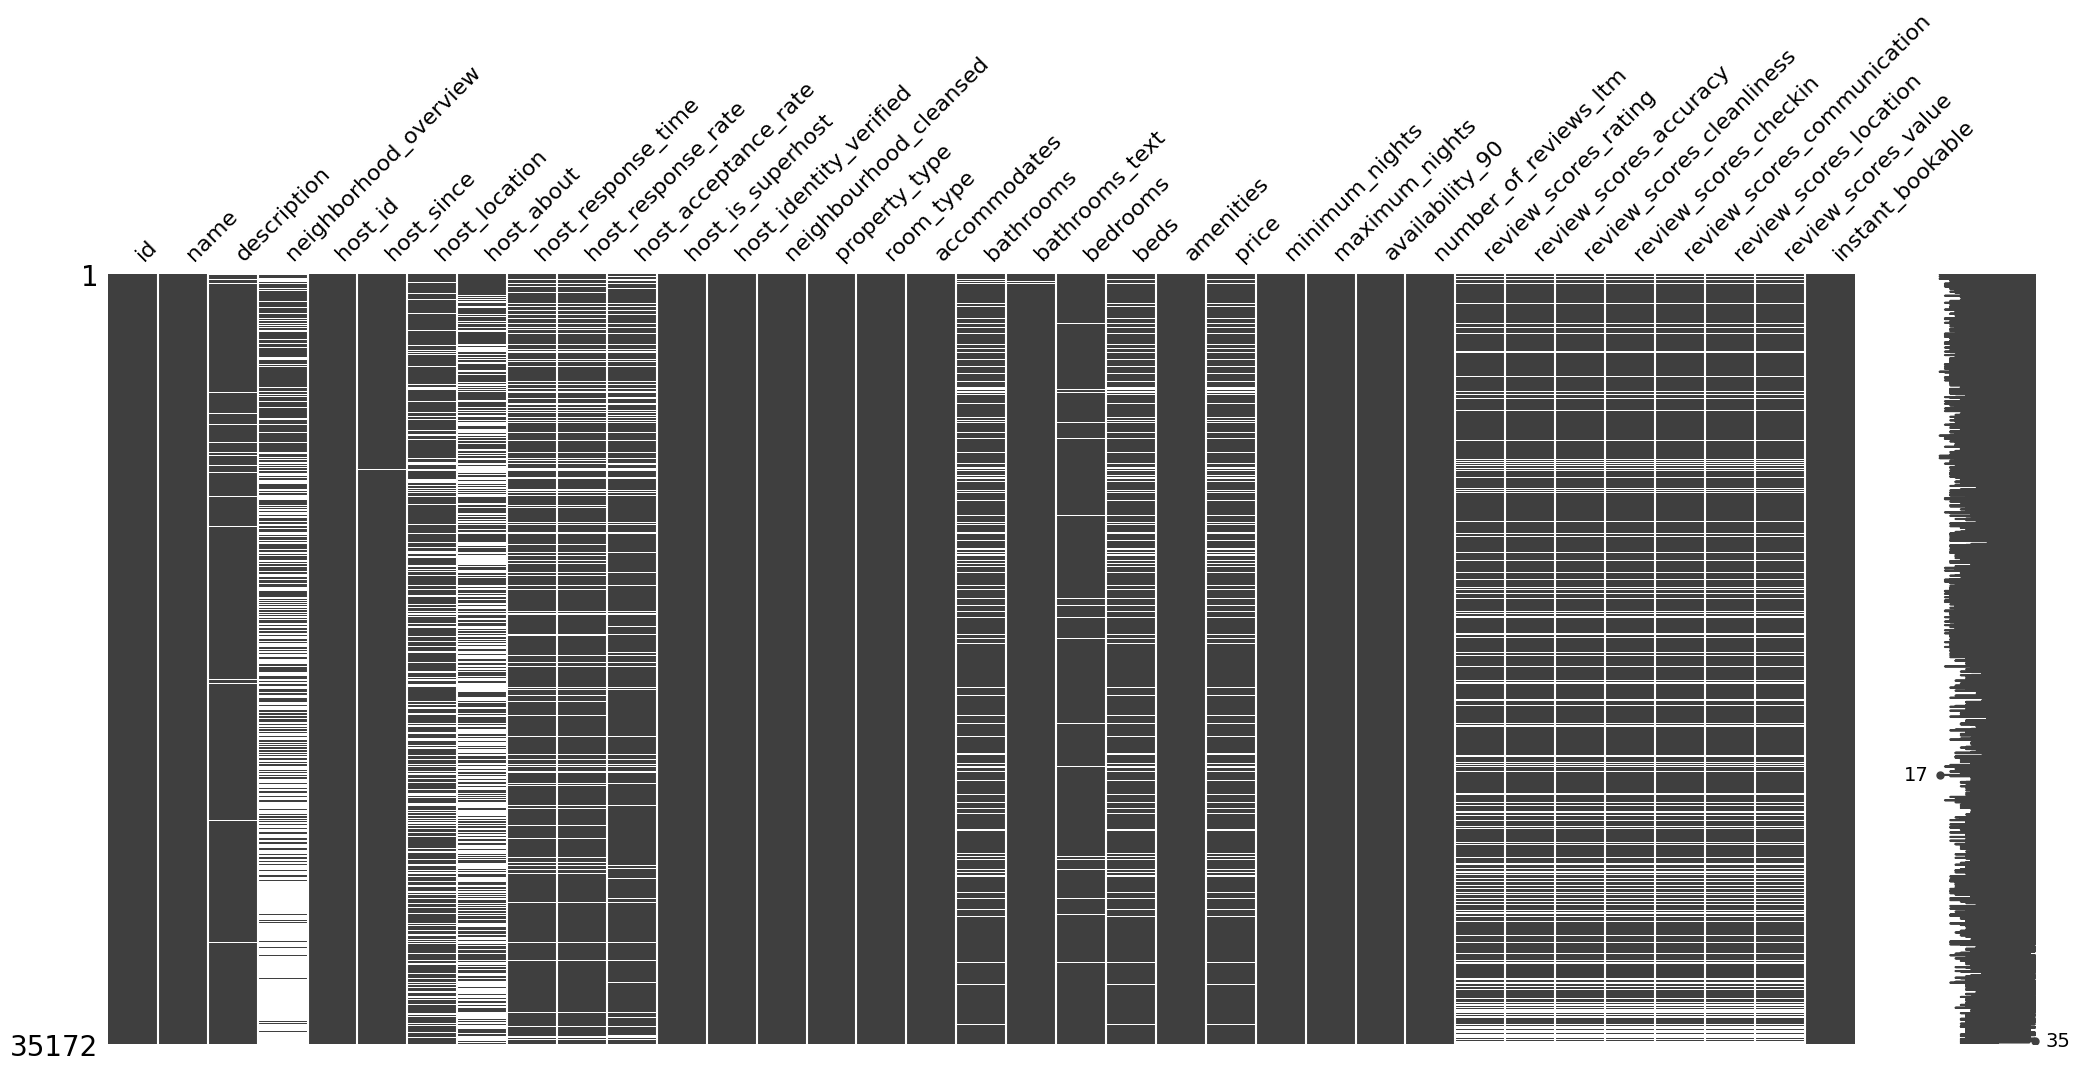

In [ ]:
msno.matrix(df_listings_limpio)

### Test de Little (MCAR)

Probamos si los faltantes son **completamente al azar (MCAR)**.  
Para eso transformamos variables categóricas/bool a códigos (manteniendo NaN), filtramos columnas constantes y luego aplicamos el test de Little.

*Esto nos orienta sobre si una imputación simple es razonable o si conviene considerar mecanismos de ausencia más complejos.*


In [ ]:
def prep_for_little(df, rare_min=3):
    X = df.copy()

    # bool -> float
    for c in X.select_dtypes(include=["bool"]).columns:
        X[c] = X[c].astype(float)

    # object/category -> codes preservando NaN (y colapsando categorías muy raras)
    for c in X.select_dtypes(include=["object","category"]).columns:
        s = X[c].astype("category")
        vc = s.value_counts(dropna=True)
        rare = vc[vc < rare_min].index
        s = s.where(~s.isin(rare), other=np.nan)
        codes = s.cat.codes.astype("float")
        X[c] = codes.replace(-1.0, np.nan)

    # forzar numérico, quitar columnas constantes / todas NaN
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.nunique(dropna=True) > 1]
    X = X.loc[:, X.notna().any()]
    return X

def little_test(df, rare_min=3):
    X = prep_for_little(df, rare_min=rare_min)
    mt = MCARTest(method="little")
    res = mt.little_mcar_test(X)   # a veces devuelve float (p-value), a veces dict

    if isinstance(res, dict):
        p = float(res.get('p_value', np.nan))
        chi2 = res.get('chi2', None)
        df_chi = res.get('df', None)
    else:
        p = float(res)
        chi2, df_chi = None, None

    print(f"Cols usadas: {X.shape[1]} | Filas: {X.shape[0]}")
    if chi2 is None:
        print(f"Little MCAR -> p={p:.6g}")
    else:
        print(f"Little MCAR -> chi2={chi2:.3f}, df={df_chi}, p={p:.6g}")
    return p, X

# Correr en cada dataset
print("\n=== Little MCAR: df_reviews ===")
p_reviews, X_reviews = little_test(df_reviews, rare_min=3)

print("\n=== Little MCAR: df_calendar ===")
p_calendar, X_calendar = little_test(df_calendar, rare_min=3)

print("\n=== Little MCAR: df_listings_limpio ===")
p_listings, X_listings = little_test(df_listings_limpio, rare_min=3)


=== Little MCAR: df_reviews ===
Cols usadas: 6 | Filas: 985786
Little MCAR -> p=0

=== Little MCAR: df_calendar ===
Cols usadas: 6 | Filas: 12837777
Little MCAR -> p=0

=== Little MCAR: df_listings_limpio ===
Cols usadas: 35 | Filas: 35172
Little MCAR -> p=0


## 🧩 Decisión de imputación

- Imputamos **solo variables numéricas** y **excluimos** columnas con >20% de nulos y columnas textuales.
- Para `df_listings_limpio`, usamos **KNNImputer (k=5)**.
- Para `df_calendar`, por escalabilidad, preferimos **imputar por agregación dentro de `listing_id`** (promedio por listing) y luego redondear reglas específicas.

Esto mantiene coherencia y reduce costos de cómputo.


In [ ]:
# KNN en columnas numéricas (excluyendo texto y columnas con alta proporción de nulos)
imputer = KNNImputer(n_neighbors=5)

cols_excluir = [
    'neighborhood_overview', 'host_location', 'host_about', 'name',
    'description', 'bathrooms_text', 'amenities', 'host_response_time',
    'host_is_superhost', 'host_identity_verified'
]
cols_a_imputar = df_listings_limpio.drop(columns=cols_excluir, errors='ignore').select_dtypes(include=np.number).columns

imputed_array = imputer.fit_transform(df_listings_limpio[cols_a_imputar])
df_listings_limpio[cols_a_imputar] = imputed_array

#Imputamos por la Moda host_response_time
df_listings_limpio['host_response_time'].fillna(df_listings_limpio['host_response_time'].mode()[0], inplace=True)

#Imputamos por Falso host_is_superhost
df_listings_limpio['host_is_superhost'].fillna(df_listings_limpio['host_is_superhost']==False, inplace=True)

# Eliminamos columnas textuales con >20% nulos
cols_a_borrar = ['host_location', 'host_about', 'neighborhood_overview']
df_listings_limpio = df_listings_limpio.drop(columns=cols_a_borrar, errors='ignore')


### Post-procesamiento de variables discretas

- `bathrooms`: valores discretos con incrementos de 0.5 → redondeamos al 0.5 más cercano.  
- `bedrooms` : forzamos discretización similar por consistencia con los datos imputados (si viniera con decimales); en la práctica se interpreta entero.
- `beds`: forzamos discretización al entero mas cercano (si viniera con decimales); en la práctica se interpreta entero.


In [ ]:
# Inspección de bathrooms
display(df_listings_limpio['bathrooms'].unique())

# Redondeo a múltiplos de 0.5
df_listings_limpio['bathrooms'] = (df_listings_limpio['bathrooms'] * 2).round().div(2)

# Para bedrooms aplicamos el mismo redondeo (si tu regla es entero estricto, podés usar .round().astype('Int64'))
df_listings_limpio['bedrooms'] = (df_listings_limpio['bedrooms'] * 2).round().div(2)

# Para Beds redondeamos al entero mas cercano
df_listings_limpio['beds'] = np.round(df_listings_limpio['beds']).astype(int)

array([ 1. ,  1.2,  1.5,  1.1,  5.5,  2.5,  2. ,  0. ,  2.4,  0.8,  3. ,
        6. ,  2.2,  1.4,  1.7,  4.5,  2.3,  4. ,  1.8,  3.5,  3.1,  2.1,
        5. ,  1.3,  1.6,  0.5,  1.9,  9. ,  8. ,  0.9, 22. ,  5.3,  7. ,
        3.4,  0.7,  6.5,  2.7, 10. ,  9.5,  2.9,  4.8,  2.8, 16. ,  7.5,
       13. ,  8.5,  2.6, 12.5,  3.8, 15. , 20. ])

## 🛠️ Nota metodológica (escalabilidad en `calendar`)

El KNN sobre millones de filas de `df_calendar` es caro en tiempo y memoria.  
Para este dataset preferimos imputar **por grupo (`listing_id`)** usando la media del listing y, luego, **redondear hacia arriba** en `minimum_nights` y `maximum_nights` para evitar incongruencias (no se aceptan fracciones de noches).


In [ ]:
# (Alternativa comentada con KNN — no se ejecuta por costo)
"""
# cols_excluir = ['date']
# cols_a_imputar = df_calendar.drop(columns=cols_excluir).select_dtypes(include=np.number).columns
# imputed_array = imputer.fit_transform(df_calendar[cols_a_imputar])
# df_calendar[cols_a_imputar] = imputed_array
# df_calendar['minimum_nights'] = np.ceil(pd.to_numeric(df_calendar['minimum_nights'], errors='coerce')).astype('Int64')
# df_calendar['maximum_nights'] = np.ceil(pd.to_numeric(df_calendar['maximum_nights'], errors='coerce')).astype('Int64')
"""

# Imputación por agregación dentro de listing_id
df_calendar['minimum_nights'] = df_calendar.groupby('listing_id')['minimum_nights'] \
    .transform(lambda x: x.fillna(x.mean()))
df_calendar['maximum_nights'] = df_calendar.groupby('listing_id')['maximum_nights'] \
    .transform(lambda x: x.fillna(x.mean()))

# Redondeo hacia arriba y tipeo entero nullable
df_calendar['minimum_nights'] = np.ceil(pd.to_numeric(df_calendar['minimum_nights'], errors='coerce')).astype('Int64')
df_calendar['maximum_nights'] = np.ceil(pd.to_numeric(df_calendar['maximum_nights'], errors='coerce')).astype('Int64')


## 🗒️ Observación sobre `df_reviews`

Los faltantes en `df_reviews` son mayormente **campos de texto**, por lo que **no se imputan** con métodos numéricos.  
Se dejan como NaN o se gestionan en pasos específicos (ej: análisis de texto).


# 🧠 Test de normalidad (Shapiro-Wilk)

Queremos ver si las variables numéricas siguen una distribución normal.  
Esto nos ayuda a decidir si usar métodos paramétricos o no.

Filtramos columnas numéricas que tengan suficiente variación y que no sean IDs,  
y aplicamos Shapiro-Wilk quitando NaN antes.

En datasets grandes como Airbnb es esperable que casi ninguna variable sea normal,
por colas largas y asimetrías (ej: `price`, `minimum_nights`, etc.).


In [ ]:
# Helper: elegir columnas para test de normalidad
def columnas_para_normalidad(df, excluir_contains=("id", "listing_id", "reviewer"), min_unique=20):
    num_cols = df.select_dtypes(include=np.number).columns
    cols = []
    for c in num_cols:
        name = c.lower()
        if any(tok in name for tok in excluir_contains):
            continue
        if pd.api.types.is_bool_dtype(df[c]):
            continue
        if df[c].nunique(dropna=True) < min_unique:
            continue
        cols.append(c)
    return cols

# Test Shapiro-Wilk para cada dataset
datasets = [df_calendar, df_reviews, df_listings_limpio]

for df in datasets:
    numerical_cols = columnas_para_normalidad(df)
    for col in numerical_cols:
        muestra = df.dropna(subset=[col])
        if muestra.shape[0] > 0:
            stat, p = shapiro(muestra[col])
            print(f"Test Shapiro para {col}: Statistics={stat:.3f}, p={p:.3f}")
        else:
            print(f"No data to perform Shapiro test for {col}")

Test Shapiro para price: Statistics=0.017, p=0.000
Test Shapiro para minimum_nights: Statistics=0.150, p=0.000
Test Shapiro para maximum_nights: Statistics=0.779, p=0.000
Test Shapiro para host_response_rate: Statistics=0.394, p=0.000
Test Shapiro para host_acceptance_rate: Statistics=0.631, p=0.000
Test Shapiro para bathrooms: Statistics=0.428, p=0.000
Test Shapiro para bedrooms: Statistics=0.588, p=0.000
Test Shapiro para beds: Statistics=0.621, p=0.000
Test Shapiro para price: Statistics=0.018, p=0.000
Test Shapiro para minimum_nights: Statistics=0.142, p=0.000
Test Shapiro para maximum_nights: Statistics=0.280, p=0.000
Test Shapiro para availability_90: Statistics=0.854, p=0.000
Test Shapiro para number_of_reviews_ltm: Statistics=0.697, p=0.000
Test Shapiro para review_scores_rating: Statistics=0.568, p=0.000
Test Shapiro para review_scores_accuracy: Statistics=0.517, p=0.000
Test Shapiro para review_scores_cleanliness: Statistics=0.620, p=0.000
Test Shapiro para review_scores_chec

### Resultado del test

Los p-values son prácticamente todos < 0.05 → rechazamos normalidad.

Esto es coherente con lo que vemos en la distribución de datos reales:
- `price` tiene cola larga a la derecha
- otras variables como `minimum_nights` y `beds` también son asimétricas

Así que **no asumimos normalidad** y más adelante usaremos métodos no paramétricos o transformaciones si hace falta.


## 🧩 Análisis de la distribución de variables numéricas

En esta sección realizamos una exploración visual de las principales variables numéricas del dataset **`df_listings_limpio`**, con el objetivo de identificar la forma de sus distribuciones, detectar asimetrías y observar posibles valores atípicos.  

Para las variables **continuas**, se utilizaron **histogramas con `sns.histplot()`** y una **curva KDE** para suavizar la forma de la distribución.  
En cada gráfico se limitaron los ejes al **80% central de los datos** (percentiles 10 y 90), para evitar que los valores extremos distorsionen la visualización.  

Las variables **discretas** se representaron mediante **gráficos de barras** que muestran la frecuencia de cada categoría.  

> 🔹 En este análisis, decidimos agrupar las variables `minimum_nights` y `maximum_nights`, dado que presentan una gran cantidad de valores distintos.



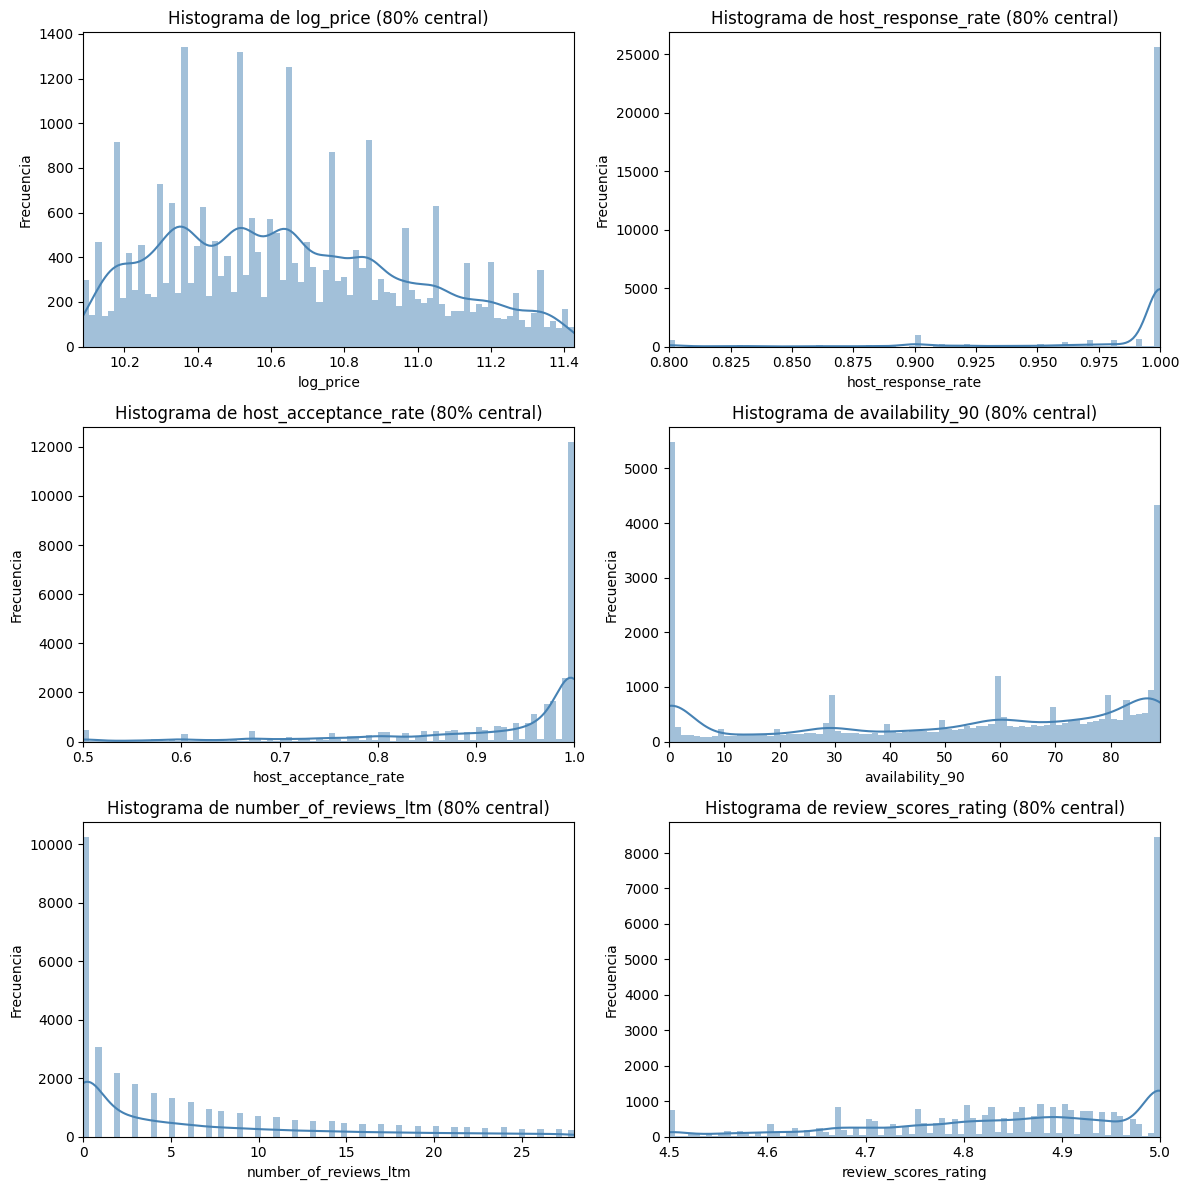

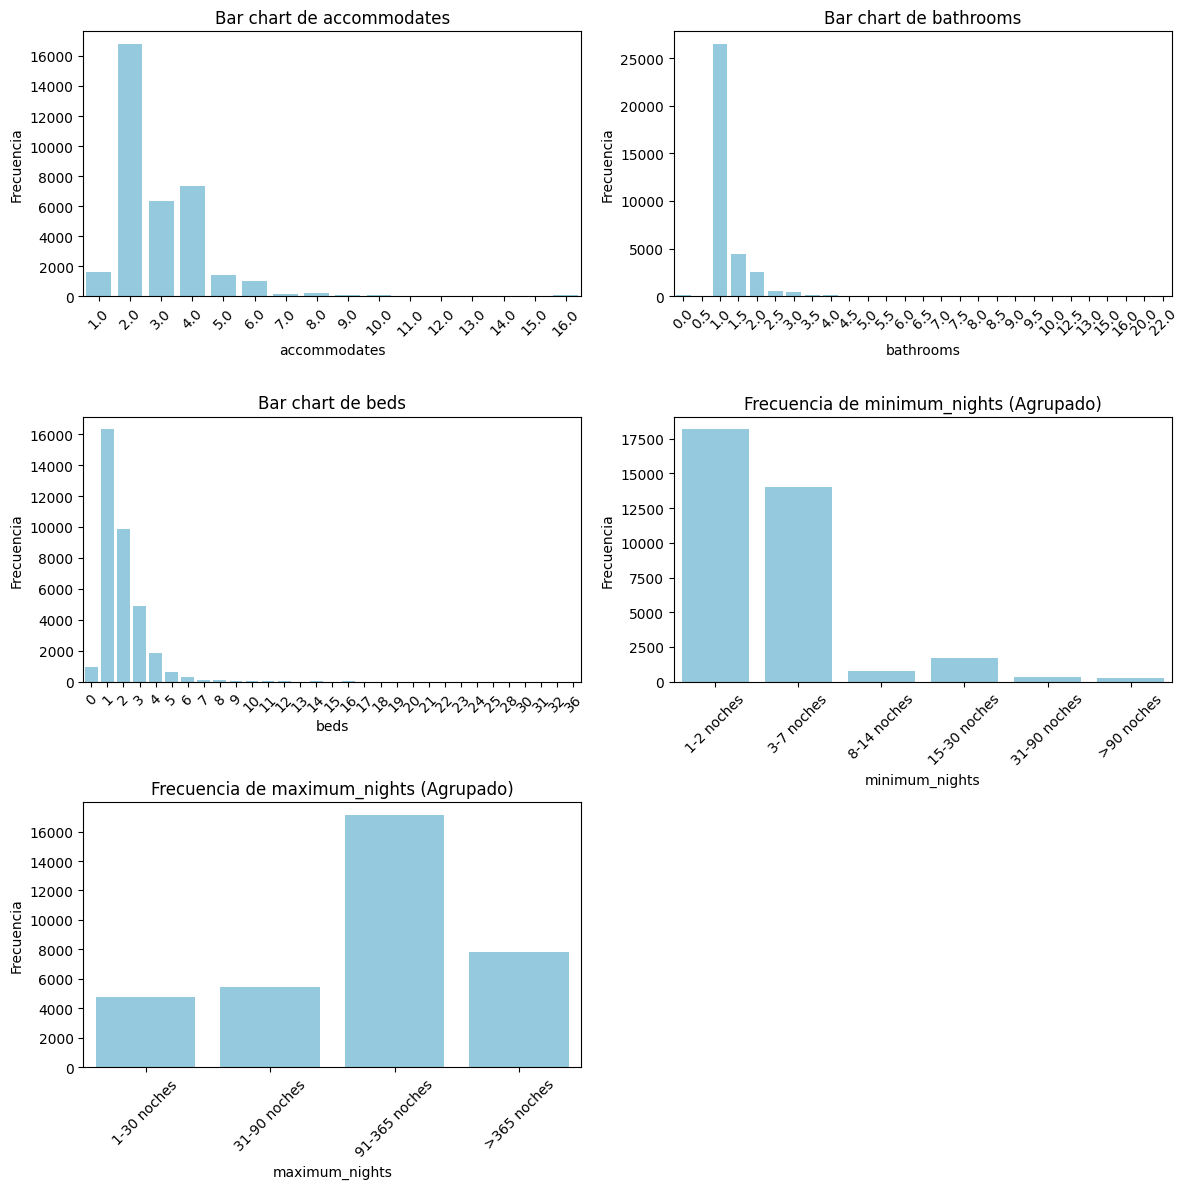

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Gráficos para df_listings_limpio
# =======================

# 1) Creamos log_price a partir de price (solo valores > 0)
mask_price_pos = df_listings_limpio['price'] > 0
df_listings_limpio.loc[mask_price_pos, 'log_price'] = np.log(df_listings_limpio.loc[mask_price_pos, 'price'])

# -----------------------
# Variables continuas → histogramas (80% central, más bins, sns.histplot)
# -----------------------
vars_continuas = [
    'log_price',
    'host_response_rate',
    'host_acceptance_rate',
    'availability_90',
    'number_of_reviews_ltm',
    'review_scores_rating'
]

n_cont = len(vars_continuas)
n_cols = 2
n_rows = (n_cont + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_continuas):
    datos = df_listings_limpio[col].dropna()
    if datos.empty:
        continue

    # ὓ0 Limites del eje X: percentiles 10 y 90 (80% central)
    p10, p90 = np.percentile(datos, [10, 90])
    datos_filtrados = datos[(datos >= p10) & (datos <= p90)]

    sns.histplot(datos_filtrados, bins=80, kde=True, ax=axes[i], color='steelblue', edgecolor=None)
    axes[i].set_title(f'Histograma de {col} (80% central)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlim(p10, p90)

# Ocultamos subplots vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# -----------------------
# Variables discretas → bar charts (accommodates, bathrooms) con binning para nights
# -----------------------
vars_discretas = [
    'accommodates',
    'bathrooms',
    'beds',
    'minimum_nights',
    'maximum_nights'
]

n_disc = len(vars_discretas)
n_cols = 2
n_rows = (n_disc + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_discretas):
    if col in ['minimum_nights', 'maximum_nights']:
        # Define bins and labels based on the column
        if col == 'minimum_nights':
            bins = [0, 2, 7, 14, 30, 90, np.inf]
            labels = ['1-2 noches', '3-7 noches', '8-14 noches', '15-30 noches', '31-90 noches', '>90 noches']
        else: # maximum_nights
            bins = [0, 30, 90, 365, np.inf]
            labels = ['1-30 noches', '31-90 noches', '91-365 noches', '>365 noches']

        # Apply binning
        binned_data = pd.cut(df_listings_limpio[col].dropna(), bins=bins, labels=labels, right=True, include_lowest=True)
        vc = binned_data.value_counts().sort_index()
        sns.barplot(x=vc.index, y=vc.values, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Frecuencia de {col} (Agrupado)')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)
    else:
        # Original plotting logic for other discrete variables
        vc = df_listings_limpio[col].value_counts().sort_index()
        sns.barplot(x=vc.index, y=vc.values, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Bar chart de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 📊 Conclusiones del análisis de distribuciones

A partir de los histogramas de las variables continuas analizadas (`log_price`, `host_response_rate`, `host_acceptance_rate`, `availability_90`, `number_of_reviews_ltm`, `review_scores_rating`, `beds`, `minimum_nights` y `maximum_nights`), se pueden observar los siguientes patrones:

- **`log_price`** presenta una distribución más equilibrada tras aplicar la transformación logarítmica, aunque aún muestra una leve asimetría a la derecha. Esto indica que la mayoría de los alojamientos tienen precios bajos o moderados, mientras que unos pocos presentan precios mucho más altos.

- **`host_response_rate`** y **`host_acceptance_rate`** se concentran fuertemente en valores cercanos a 1, lo que refleja que la mayoría de los anfitriones responden y aceptan solicitudes casi siempre. Son variables muy sesgadas hacia el extremo superior.

- **`availability_90`** tiene una distribución bimodal, con grupos de alojamientos que están disponibles casi todo el tiempo y otros que se alquilan muy poco, reflejando distintos tipos de estrategias de alquiler.

- **`number_of_reviews_ltm`** presenta una clara asimetría positiva: la mayoría de los alojamientos tienen pocas reseñas recientes, mientras que unos pocos concentran un número muy alto.

- **`review_scores_rating`** muestra valores muy concentrados entre 4.7 y 5, lo que sugiere una tendencia general a buenas calificaciones, con poca dispersión.

- En cuanto a **`beds`**, **`minimum_nights`** y **`maximum_nights`**, se decidió tratarlas como variables continuas debido a su gran cantidad de valores distintos.  
  Todas presentan fuerte asimetría hacia la derecha, con la mayoría de los alojamientos ofreciendo pocas camas y requisitos de estadía mínima y máxima bajos, pero algunos casos extremos con valores muy elevados.

En conjunto, las distribuciones muestran **comportamientos esperables en el mercado de alojamientos**: predominio de unidades pequeñas, precios concentrados en niveles medios-bajos, alta tasa de respuesta de los anfitriones y buena reputación promedio.


### Check de normalidad para log(price)

Probamos formalmente si log(price) se acerca más a normalidad.
Si no mejora lo suficiente, descartamos esa variable auxiliar.

In [ ]:
log_price_listings = df_listings_limpio['log_price'].dropna()

print("Test shapiro para log_price en df_listing",shapiro(log_price_listings))

Test shapiro para log_price en df_listing ShapiroResult(statistic=np.float64(0.87842521646144), pvalue=np.float64(7.162450386946606e-94))


#### Conclusión de esta parte

El log ayuda pero **no alcanza para lograr normalidad clara**.

Decidimos **no usar log_price** y seguir con métodos que no requieren normalidad.


In [ ]:
del df_listings_limpio['log_price']

# Detección de outliers

##  Outliers univariados (Box-Cox + Z-score)

Acá buscamos detectar valores extremos sin asumir normalidad de entrada.

La idea es:
- Transformar cada variable con **Box-Cox** para estabilizar varianza
- Si hay valores ≤ 0, mover la variable para poder aplicar Box-Cox
- Calcular z-scores sobre la transformada
- Marcar como outliers los que están más allá de |3|

Esto lo usamos sólo para **diagnóstico**: no eliminamos nada todavía, porque muchos valores extremos (especialmente en `price`) son reales y representan alojamientos premium.


In [ ]:
"""# --- Función 1: transforma usando Box-Cox, moviendo si hay ≤0 ---
def transform_boxcox_shift(s: pd.Series):
    notna = s.notna().values
    x = s.values[notna]
    if x.size == 0:
        return np.array([]), None, "sin_datos", notna

    # Si hay valores ≤ 0, mover toda la variable
    shift = 0
    if np.any(x <= 0):
        shift = -x.min() + 1e-6
        x = x + shift

    try:
        x_t, lam = boxcox(x)
        metodo = f"Box-Cox (shift={shift:.3f})" if shift > 0 else "Box-Cox"
    except Exception:
        return np.array([]), None, "error_BoxCox", notna

    return x_t, lam, metodo, notna

# --- Función 2: busca outliers con z-score sobre la transformada ---
def outliers_on_transformed(s: pd.Series, threshold: float = 3.0):
    x_t, lam, metodo, notna = transform_boxcox_shift(s)
    if x_t.size == 0:
        mask = pd.Series(False, index=s.index)
        return mask, {"count": 0, "lambda": None, "method": metodo}

    std = np.std(x_t)
    if std == 0 or np.isnan(std):
        mask_valid = np.zeros_like(x_t, dtype=bool)
    else:
        z = (x_t - np.mean(x_t)) / std
        mask_valid = np.abs(z) > threshold

    mask_full = pd.Series(False, index=s.index)
    mask_full.iloc[notna] = mask_valid
    return mask_full, {"count": int(mask_valid.sum()), "lambda": lam, "method": metodo}

# --- Loop sobre los dataframes ---
for df_name, df in {"calendar": df_calendar, "reviews": df_reviews, "listings": df_listings_limpio}.items():
    df = df.copy()
    numerical_cols = df.select_dtypes(include=np.number).columns
    print(f"\n📊 Analizando {df_name} ({len(numerical_cols)} variables numéricas)")

    resultados = {}
    for col in numerical_cols:
        mask, info = outliers_on_transformed(df[col], threshold=3)
        resultados[col] = (info["count"], info["lambda"], info["method"])
        df[f"{col}_outlier"] = mask

    resumen = pd.DataFrame(resultados, index=["count", "lambda", "method"]).T
    display(resumen)

df_listings_limpio.info()"""

'# --- Función 1: transforma usando Box-Cox, moviendo si hay ≤0 ---\ndef transform_boxcox_shift(s: pd.Series):\n    notna = s.notna().values\n    x = s.values[notna]\n    if x.size == 0:\n        return np.array([]), None, "sin_datos", notna\n\n    # Si hay valores ≤ 0, mover toda la variable\n    shift = 0\n    if np.any(x <= 0):\n        shift = -x.min() + 1e-6\n        x = x + shift\n\n    try:\n        x_t, lam = boxcox(x)\n        metodo = f"Box-Cox (shift={shift:.3f})" if shift > 0 else "Box-Cox"\n    except Exception:\n        return np.array([]), None, "error_BoxCox", notna\n\n    return x_t, lam, metodo, notna\n\n# --- Función 2: busca outliers con z-score sobre la transformada ---\ndef outliers_on_transformed(s: pd.Series, threshold: float = 3.0):\n    x_t, lam, metodo, notna = transform_boxcox_shift(s)\n    if x_t.size == 0:\n        mask = pd.Series(False, index=s.index)\n        return mask, {"count": 0, "lambda": None, "method": metodo}\n\n    std = np.std(x_t)\n    if st

### 📝 Conclusión univariada

Encontramos muchos valores extremos, lo cual era esperable.  
Especialmente en `price`, donde hay una cola derecha marcada con alojamientos de lujo.

Decidimos **no eliminar outliers univariados** porque reflejan casos reales del mercado.


## 🌲 Outliers multivariados (Isolation Forest + LOF)

Ahora buscamos outliers considerando todas las variables juntas,
porque algo que parece extremo en una sola columna puede ser coherente cuando miramos el conjunto (ej: casas grandes = precios altos).

Probamos dos enfoques:
- **Isolation Forest** → robusto, no depende tanto de densidad local
- **Local Outlier Factor** → referencia adicional, pero puede ser inestable con alta dimensionalidad

Excluimos columnas tipo ID porque no aportan a este análisis.


###  ¿Por qué usamos Isolation Forest y LOF en vez de Mahalanobis?

Para la detección de outliers multivariados evaluamos varias alternativas. Decidimos usar **Isolation Forest** y **Local Outlier Factor (LOF)**, y no la distancia **Mahalanobis**, por motivos metodológicos:

#### ❌ Limitaciones de Mahalanobis
- Asume **normalidad multivariada**, algo que no se cumple en este dataset (precio, nights, reviews presentan fuertes asimetrías).
- Es **muy sensible** a valores extremos: los outliers reales distorsionan la matriz de covarianzas que la distancia usa como base.
- Supone relaciones **lineales** entre variables, lo cual no se ajusta a datos de Airbnb.
- Con muchas variables o colinealidad, la distancia se vuelve **inestable** y poco confiable.
  
Por estas razones, Mahalanobis tiende a **sobre-detectar** outliers o directamente **no detectar los reales**.

#### ✅ Ventajas de Isolation Forest
- No requiere supuestos de distribución: **funciona bien con datos no normales**.
- Identifica outliers por su **facilidad para ser aislados**, incluso con relaciones no lineales.
- Es **robusto** a escalas distintas, ruido y colas largas.
- Escala bien con datasets grandes (como listings).

#### ✅ Ventajas de Local Outlier Factor (LOF)
- Detecta **outliers locales**, es decir, puntos que son raros en su vecindario pero no necesariamente globalmente.
- Se basa en densidad, permitiendo detectar **patrones complejos** entre variables.
- Sirve como **validación complementaria** al Isolation Forest.

#### 📌 Conclusión
En conjunto, **Isolation Forest + LOF** permiten una detección más robusta y consistente con la estructura real del dataset, sin asumir normalidad ni linealidad.  
La distancia **Mahalanobis no es adecuada** para este tipo de datos altamente heterogéneos y con distribuciones sesgadas.


In [ ]:
# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)

# columnas numéricas sin IDs
num_cols = df_listings_limpio.select_dtypes(include=np.number).columns.tolist()
id_like = [c for c in num_cols if 'id' in c.lower()]
feat_cols = [c for c in num_cols if c not in id_like]

print(feat_cols)

df_listings_limpio["outlier_iso"] = iso.fit_predict(df_listings_limpio[feat_cols])

df_out_iforest = df_listings_limpio[df_listings_limpio["outlier_iso"] == -1]

print("Outliers detectados (Isolation Forest):")
print(df_out_iforest[['id','price','host_id','bathrooms','bedrooms','outlier_iso']])


['host_response_rate', 'host_acceptance_rate', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'availability_90', 'number_of_reviews_ltm', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
Outliers detectados (Isolation Forest):
                 id     price      host_id  bathrooms  bedrooms  outlier_iso
10     6.880000e+04  362325.0     221405.0        5.5       4.0           -1
24     7.220400e+04  340722.0     373629.0        2.0       4.0           -1
38     7.799400e+04   48005.0      64880.0        0.0       1.0           -1
83     1.072590e+05  404334.0     555693.0        6.0       7.0           -1
118    1.544300e+05   21004.0     742738.0        1.0       1.0           -1
...             ...       ...          ...        ...       ...          ...
34944  1.337804e+18   16803.0  673989632.0        3.

In [ ]:
# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_listings_limpio["outlier_lof"] = lof.fit_predict(df_listings_limpio[feat_cols])

df_out_lof = df_listings_limpio[df_listings_limpio["outlier_lof"] == -1]

print("Outliers detectados (Local Outlier Factor):")
print(df_out_lof[['id','price','bathrooms','bedrooms','outlier_iso','outlier_lof']])

Outliers detectados (Local Outlier Factor):
                 id    price  bathrooms  bedrooms  outlier_iso  outlier_lof
19     3.192000e+04  99709.8        1.0       1.0            1           -1
33     4.853500e+04  52511.0        2.0       1.0            1           -1
44     6.128200e+04  38858.0        2.0       1.0            1           -1
49     7.835100e+04  54611.0        1.5       1.0            1           -1
67     8.594900e+04  20809.0        1.0       1.0            1           -1
...             ...      ...        ...       ...          ...          ...
35044  1.342744e+18  42102.0        1.0       1.0            1           -1
35054  1.339334e+18  12844.0        2.5       2.0            1           -1
35091  1.340182e+18  31507.0        1.0       1.0            1           -1
35100  1.343550e+18  41862.0        1.5       2.0            1           -1
35151  1.341300e+18  35770.0        1.0       1.0            1           -1

[1759 rows x 6 columns]


In [ ]:
#muestro los que tienen outlier_iso o outlier_lof
df_listings_limpio[(df_listings_limpio['outlier_iso'] == -1) | (df_listings_limpio['outlier_lof'] == -1)]

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,outlier_iso,outlier_lof
10,6.880000e+04,Recoleta great penthouse w/private terrace &g...,"In the heart of the Recoleta District, the mos...",221405.0,2010-09-02,within a day,1.000,0.830,False,True,...,4.540,4.520,4.270,4.870,4.890,4.970,4.430,False,-1,1
19,3.192000e+04,Beautifull apartment in Belgrano!,NaN,137373.0,2010-06-02,within an hour,1.000,1.000,False,False,...,4.756,4.816,4.658,4.848,4.852,4.858,4.708,False,1,-1
24,7.220400e+04,Beautiful house in Palermo SOHO,Gorriti rental house is at the heart of Palerm...,373629.0,2011-02-01,within an hour,1.000,0.770,True,True,...,4.990,4.970,4.850,4.990,4.990,5.000,4.880,False,-1,1
33,4.853500e+04,Elegant apartment in downtown Bs.As,Minimum rental period: 6 months,221044.0,2010-09-02,within an hour,1.000,0.800,False,True,...,4.846,4.868,4.790,4.936,4.938,4.940,4.842,False,1,-1
38,7.799400e+04,Studio 1A - Corazon de San Telmo,"This unit on 1st floor, particularly street ov...",64880.0,2009-12-21,within an hour,0.950,0.940,True,True,...,4.000,3.710,4.140,4.430,4.570,4.860,4.140,True,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35091,1.340182e+18,departamento luminoso,"This lovely apartment, located on the front, v...",340990355.0,2020-03-09,within a few hours,1.000,0.978,False,True,...,4.700,4.900,4.900,5.000,4.900,4.900,4.900,True,1,-1
35100,1.343550e+18,Tu hogar acogedor en Caballito,Enjoy the comfort of a welcoming home in Cabal...,461085342.0,2022-05-26,within an hour,0.930,0.000,False,True,...,4.700,4.900,4.900,5.000,4.900,4.900,4.900,True,1,-1
35101,1.343589e+18,Luxury House in of Heart of Belgrano,"3 ensuite bedrooms, rooftop BBQ and abundant a...",673167607.0,2025-01-15,within an hour,0.998,0.644,False,True,...,4.700,4.900,4.900,5.000,4.900,4.900,4.900,False,-1,1
35117,1.343646e+18,Seguridad 24x7 y 2 cocheras,"Elegant apartment in Caballito with 5 rooms, i...",153190460.0,2017-10-03,within an hour,1.000,0.680,False,True,...,4.700,4.900,4.900,5.000,4.900,4.900,4.900,False,-1,1


### 📝 Conclusión multivariada

Ambos métodos marcan alrededor de un 5% de casos.

Isolation Forest se comportó más estable, así que usamos ese como criterio final para limpieza.


## 🎢 PCA — solo diagnóstico dimensional

Hicimos PCA para entender la estructura de la varianza.  
El “codo” aparece cerca de 10 componentes (~85% varianza explicada).

No usamos PCA para detectar outliers porque podría ocultar anomalías en componentes de baja varianza.

¿Por qué escalamos antes de aplicar PCA?

Escalamos las variables porque PCA se basa en **varianzas y covarianzas**, por lo que las variables con mayor escala dominarían el análisis (por ejemplo, `price` frente a `review_scores_rating`).  
Al estandarizar:

- todas las variables pasan a la **misma escala** (media 0, desvío 1)  
- se evitan sesgos por unidades distintas  
- los componentes principales reflejan **patrones reales** y no diferencias de magnitud  

En resumen: **escalar asegura un PCA estable, comparable y no sesgado**.


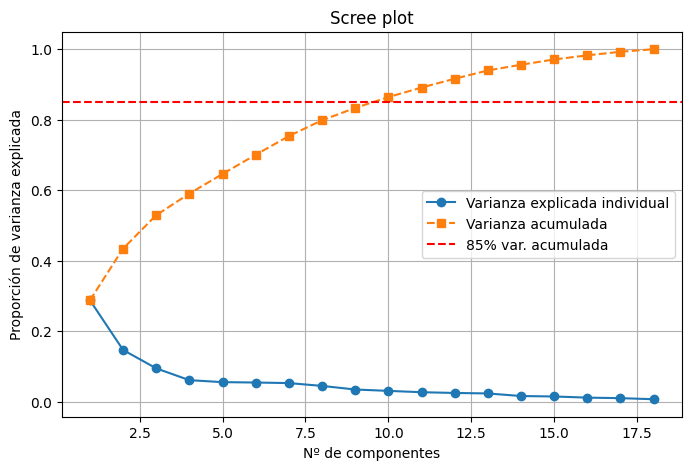

In [ ]:
X = StandardScaler().fit_transform(df_listings_limpio[feat_cols].iloc[1::])

pca = PCA()
pca.fit(X)

var_exp = pca.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_exp)+1), var_exp, 'o-', label="Varianza explicada individual")
plt.plot(range(1, len(var_exp)+1), cum_var_exp, 's--', label="Varianza acumulada")
plt.axhline(y=0.85, color='red', linestyle='--', label='85% var. acumulada')
plt.xlabel('Nº de componentes')
plt.ylabel('Proporción de varianza explicada')
plt.title('Scree plot')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
vals = pd.unique(df_listings_limpio['outlier_iso'].dropna())
out_flag = -1 if (-1 in vals) else 1

mask_out = df_listings_limpio['outlier_iso'].eq(out_flag)
outliers_guardados = df_listings_limpio.loc[mask_out].copy()

n0 = len(df_listings_limpio)
df_listings_limpio = df_listings_limpio.loc[~mask_out].reset_index(drop=True)
print(f"Eliminadas: {mask_out.sum()} filas ({mask_out.mean():.2%}). Restantes: {len(df_listings_limpio)}/{n0}")

#borramos las columnas de outlier
df_listings_limpio.drop(columns=['outlier_iso', 'outlier_lof'], inplace=True)

Eliminadas: 1759 filas (5.00%). Restantes: 33413/35172


## ✅ Resumen de esta sección

- Evaluamos outliers univariados → no los eliminamos (siguen siendo válidos)
- Usamos Isolation Forest + LOF para análisis multivariado
- Elegimos **Isolation Forest** por mayor estabilidad
- Eliminamos ~5% de casos extremos y guardamos backup


# Conclusiones preliminares

### Hipotesis 1:



Los precios en barrios turísticos (Palermo, Recoleta, San Telmo) son sistemáticamente más altos que en barrios periféricos.

#### 🏙️ Agrupación de barrios

Se agruparon los barrios de CABA en dos categorías para comparar precios entre zonas **turísticas** y **no turísticas**.  

- **Barrios turísticos:** Palermo, Recoleta, San Telmo, Monserrat, Puerto Madero, Retiro, Belgrano, Núñez y San Nicolás.  
- **Barrios no turísticos:** el resto de las zonas.

In [ ]:
#Agrupar barrios
tur = ['Palermo', 'Retiro', 'San Nicolas', 'Puerto Madero', 'San Telmo', 'Monserrat', 'Constitucion', 'Nuñez', 'Belgrano', 'Colegiales']
#todos los demas en PERI
all_neighbourhoods = df_listings_limpio['neighbourhood_cleansed'].unique()
peri = [neighbourhood for neighbourhood in all_neighbourhoods if neighbourhood not in tur]

tur_price = df_listings_limpio[df_listings_limpio['neighbourhood_cleansed'].isin(tur)]['price'].dropna()
peri_price = df_listings_limpio[df_listings_limpio['neighbourhood_cleansed'].isin(peri)]['price'].dropna()

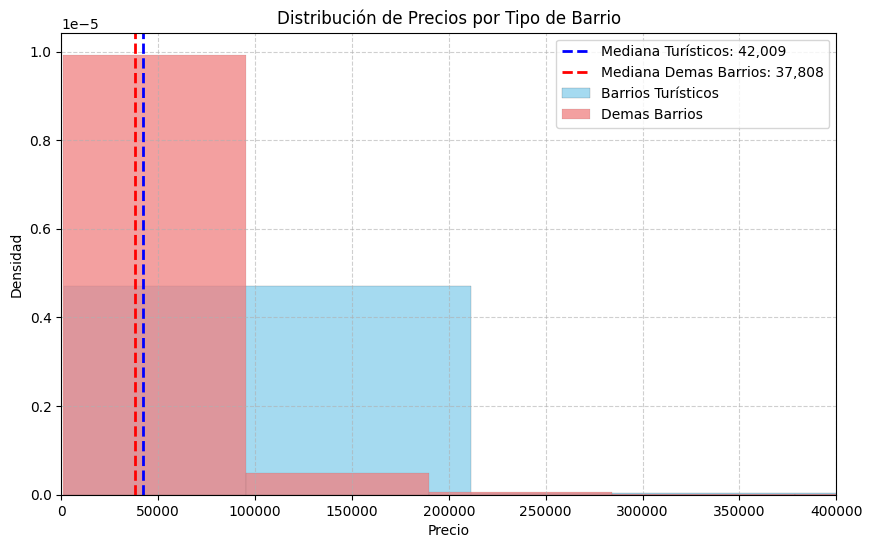

In [ ]:
# Calcular medianas (ya que no hay normalidad)
med_tur = tur_price.median()
med_peri = peri_price.median()

plt.figure(figsize=(10, 6))
sns.histplot(tur_price, color="skyblue", label="Barrios Turísticos", bins=500, stat="density", common_norm=False)
sns.histplot(peri_price, color="lightcoral", label="Demas Barrios", bins=500, stat="density", common_norm=False)

plt.axvline(med_tur, color='blue', linestyle='dashed', linewidth=2, label=f'Mediana Turísticos: {med_tur:,.0f}')
plt.axvline(med_peri, color='red', linestyle='dashed', linewidth=2, label=f'Mediana Demas Barrios: {med_peri:,.0f}')

plt.title('Distribución de Precios por Tipo de Barrio')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 400000)
plt.show()

#### Conclusion preliminar:
  
El precio de los barrios turisticos muestra asimetría hacia la derecha y outliers explicables por capacidad o ubicación. Los **barrios turísticos** parecen presentar precios más altos.  


#### Confirmacion a traves de test estadístico

El objetivo es analizar si existen diferencias significativas en los **precios promedio** entre ambos grupos.  
Para esto, primero se evalúa la **normalidad de las distribuciones** con el **test de Shapiro-Wilk**, y según el resultado se elige entre **ANOVA** (si normal) o **Kruskal-Wallis** (si no normal).

---

###  Fundamentación teórica

####  Test de Shapiro-Wilk
Evalúa si los datos provienen de una distribución normal.  
- **H₀:** los datos son normales.  
- **H₁:** los datos no son normales.  
Si el **p-valor ≤ 0.05**, se rechaza la normalidad.  
Este test es necesario porque el ANOVA requiere datos aproximadamente normales.


---

####  Kruskal-Wallis
Alternativa **no paramétrica** al ANOVA, usada cuando los datos **no son normales** o presentan **outliers**.  
- **H₀:** las distribuciones (o medianas) son iguales.  
- **H₁:** al menos una difiere.  
Compara los **rangos** en lugar de las medias, siendo más robusto ante asimetrías y valores extremos, comunes en los precios.

---

###  Conclusión metodológica
1. Aplicar **Shapiro-Wilk** → determinar normalidad.  
2. Si **normal** → usar **ANOVA** para comparar medias.  
3. Si **no normal** → usar **Kruskal-Wallis** para comparar medianas.  

De esta forma se garantiza una comparación estadísticamente válida de los precios entre barrios turísticos y no turísticos.


In [ ]:
# Test de normalidad para precios en barrios turísticos y no turísticos
print("Test Shapiro para precios en barrios turísticos:", shapiro(tur_price))
print("Test Shapiro para precios en los demas barrios:", shapiro(peri_price))

Test Shapiro para precios en barrios turísticos: ShapiroResult(statistic=np.float64(0.013782878534784992), pvalue=np.float64(3.7642421374174683e-137))
Test Shapiro para precios en los demas barrios: ShapiroResult(statistic=np.float64(0.016996436567252582), pvalue=np.float64(9.927138072408207e-121))


In [ ]:
# Realizar el test de Kruskal-Wallis ya que los datos no son normales
statistic, p_value = stats.kruskal(tur_price, peri_price)

print(f"\nTest de Kruskal-Wallis:")
print(f"Statistics={statistic:.4f}, p={p_value:.4f}")

if p_value < 0.05:
    print("Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre los precios medianos de los barrios turísticos y los demás barrios.")
else:
    print("Resultado: No rechazamos la hipótesis nula. No existe una diferencia estadísticamente significativa entre los precios medianos de los barrios turísticos y los demás barrios.")


Test de Kruskal-Wallis:
Statistics=412.7423, p=0.0000
Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre los precios medianos de los barrios turísticos y los demás barrios.


####  Conclusión

El test de Kruskal-Wallis mostró diferencias estadísticamente significativas en los precios entre barrios turísticos y no turísticos (**p < 0.05**).  
Las medianas reflejan que los **barrios turísticos presentan precios más altos** en promedio (≈42.000) que los **demás barrios** (≈37.800).  
Esto confirma que la ubicación en zonas turísticas impacta de forma relevante sobre el precio de los alojamientos.


### Hipótesis 2:
La presencia de **amenities clave** (gym, pileta, estacionamiento gratuito) incrementa tanto el **precio** como la **calificación promedio** del alojamiento.

---

#### 🧩 Identificación de amenities relevantes

El objetivo es analizar si ciertas comodidades frecuentes en alojamientos de alta gama (como **gimnasio, piscina y estacionamiento gratuito**) tienen un impacto visible en el precio y en las valoraciones de los huéspedes.

Primero se extraen y limpian los **amenities únicos** del dataset, y se crean **variables binarias** (`has_gym`, `has_pool`, `has_free_parking`) que indiquen su presencia o ausencia en cada publicación.

> Este paso convierte un campo de texto no estructurado en información analizable y comparable entre listados.

---

#### ⚙️ Creación de combinaciones de amenities

Se genera una nueva columna llamada **`amenity_combination`**, que resume las posibles combinaciones entre los tres amenities clave:

- `all_three` → tiene gym, pool y free parking.  
- `gym_and_pool`, `pool_and_free_parking`, etc.  
- `none` → no tiene ninguno de los tres.

Esto permite comparar grupos con distintos niveles de “completitud” de servicios y observar si hay patrones en precio o en calificación.



In [ ]:
all_amenities = [item.strip('[]" ') for sublist in df_listings_limpio['amenities'] for item in sublist.split(',')]

unique_amenities = set(all_amenities)

pool_amenities = [amenity for amenity in sorted(list(unique_amenities)) if 'free ' in amenity.lower() and ' parking ' in amenity.lower()]

print("Unique Amenities containing 'pool':")
for amenity in pool_amenities:
    print(amenity)

Unique Amenities containing 'pool':
Free driveway parking on premises
Free driveway parking on premises \u2013 1 space
Free driveway parking on premises \u2013 6 spaces
Free parking garage on premises
Free parking garage on premises \u2013 1 space
Free parking garage on premises \u2013 100 spaces
Free parking garage on premises \u2013 2 spaces
Free parking garage on premises \u2013 28 spaces
Free parking garage on premises \u2013 52 spaces
Free parking on premises
Free parking on premises \u2013 1 space
Free parking on premises \u2013 2 spaces
Free parking on premises \u2013 68 spaces


In [ ]:
df_listings_limpio['has_gym'] = df_listings_limpio['amenities'].str.contains(' gym ', case=False, na=False)
df_listings_limpio['has_pool'] = df_listings_limpio['amenities'].str.contains(' pool ', case=False, na=False)
df_listings_limpio['has_free_parking'] = df_listings_limpio['amenities'].str.contains('free ') & df_listings_limpio['amenities'].str.contains(' parking', case=False, na=False)

df_listings_limpio[['amenities', 'has_gym', 'has_pool', 'has_free_parking']].head()

,amenities,has_gym,has_pool,has_free_parking
0,"[""Bathtub"", ""Air conditioning"", ""Bed linens"", ...",False,False,False
1,"[""Bathtub"", ""Air conditioning"", ""TV"", ""Heating...",False,False,False
2,"[""Washer"", ""Air conditioning"", ""Dryer"", ""TV wi...",False,False,False
3,"[""Backyard"", ""Air conditioning"", ""Patio or bal...",False,False,False
4,"[""Bathtub"", ""Shared outdoor pool - available a...",False,True,False


In [ ]:
def get_amenity_combination(row):
    has_gym = row['has_gym']
    has_pool = row['has_pool']
    has_free_parking = row['has_free_parking']

    if has_gym and has_pool and has_free_parking:
        return 'all_three'
    elif has_gym and has_pool:
        return 'gym_and_pool'
    elif has_gym and has_free_parking:
        return 'gym_and_free_parking'
    elif has_pool and has_free_parking:
        return 'pool_and_free_parking'
    elif has_gym:
        return 'gym_only'
    elif has_pool:
        return 'pool_only'
    elif has_free_parking:
        return 'free_parking_only'
    else:
        return 'none'

df_listings_limpio['amenity_combination'] = df_listings_limpio.apply(get_amenity_combination, axis=1)

display(df_listings_limpio['amenity_combination'].value_counts())

,count
amenity_combination,
none,28899
pool_only,1909
gym_and_pool,1095
gym_only,979
all_three,306
gym_and_free_parking,95
free_parking_only,93
pool_and_free_parking,37


In [ ]:
amenity_price_rating = df_listings_limpio.groupby('amenity_combination')[['price', 'review_scores_rating']].agg('mean')
display(amenity_price_rating)

,price,review_scores_rating
amenity_combination,,
all_three,76355.519608,4.887850
free_parking_only,131154.907527,4.867398
gym_and_free_parking,63262.069474,4.884589
gym_and_pool,70268.648767,4.841898
gym_only,63937.549949,4.834539
none,86070.030306,4.819946
pool_and_free_parking,58882.675676,4.836973
pool_only,53928.919539,4.828359



#### 📊 Análisis exploratorio: precio y review promedio

Se agrupan los datos por `amenity_combination` y se calculan los **promedios de precio** y de **review_scores_rating**.  
Luego se visualizan con dos gráficos de barras:

- **Izquierda:** precio promedio ordenado de mayor a menor.  
- **Derecha:** puntaje promedio ordenado por calificación.

> Estos gráficos permiten observar tendencias iniciales: si los alojamientos con más amenities clave tienden a cobrar más o recibir mejores puntuaciones.


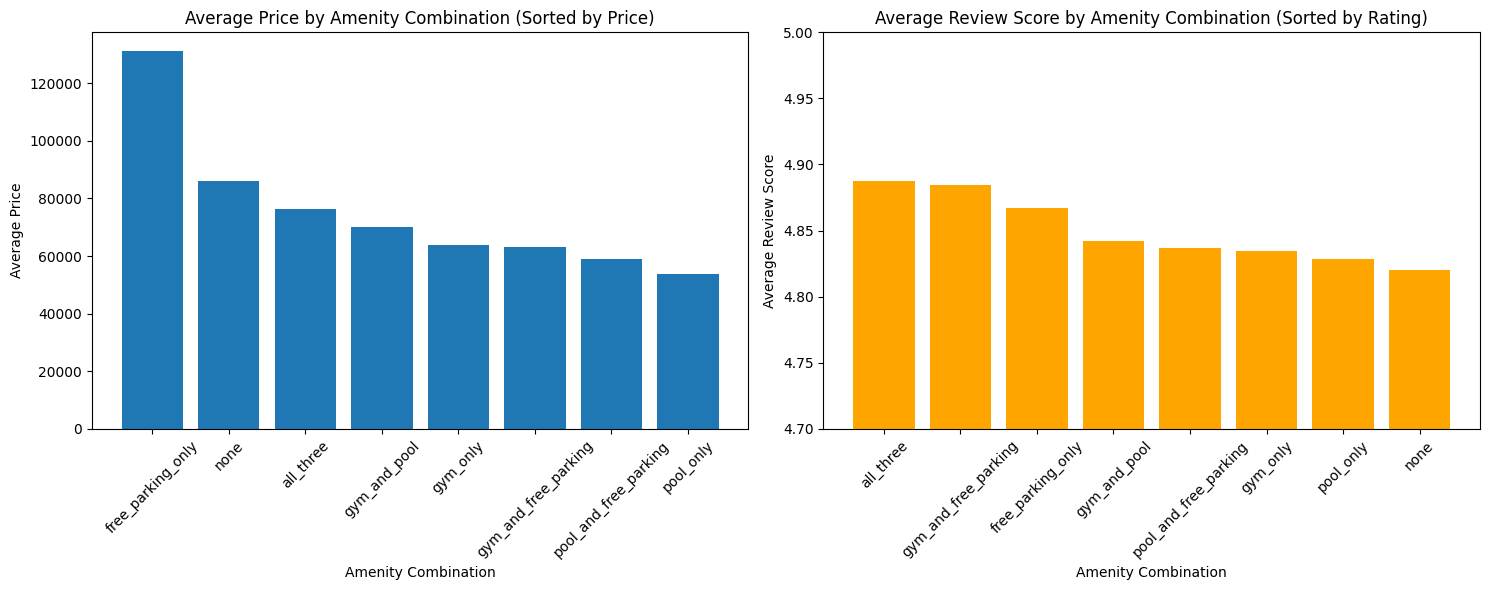

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

amenity_price_rating_sorted_price = amenity_price_rating.sort_values('price', ascending=False)
axes[0].bar(amenity_price_rating_sorted_price.index, amenity_price_rating_sorted_price['price'])
axes[0].set_title('Average Price by Amenity Combination (Sorted by Price)')
axes[0].set_xlabel('Amenity Combination')
axes[0].set_ylabel('Average Price')
axes[0].tick_params(axis='x', rotation=45)

amenity_price_rating_sorted_rating = amenity_price_rating.sort_values('review_scores_rating', ascending=False)
axes[1].bar(amenity_price_rating_sorted_rating.index, amenity_price_rating_sorted_rating['review_scores_rating'], color='orange')
axes[1].set_title('Average Review Score by Amenity Combination (Sorted by Rating)')
axes[1].set_xlabel('Amenity Combination')
axes[1].set_ylabel('Average Review Score')
axes[1].tick_params(axis='x', rotation=45)
plt.ylim(4.7, 5)
plt.tight_layout()
plt.show()


#### 💡 Conclusión preliminar

A simple vista, no se observan grandes diferencias de precio entre la mayoría de combinaciones, **excepto** en los casos con *free parking only*, que presentan precios algo diferentes.  
En cambio, sí se nota una **relación positiva entre la cantidad de amenities clave y la calificación promedio**: a más servicios, mejor review score.



#### 📏 Confirmación estadística

Para confirmar si estas diferencias son significativas, se realiza el siguiente procedimiento:

1. **Test de Shapiro–Wilk** en cada subgrupo de `amenity_combination`  
   → Verifica la normalidad de `price` y `review_scores_rating`.
2. Dado que los datos **no son normales**, se aplica el **test no paramétrico de Kruskal–Wallis** sobre ambos indicadores.

---

### Fundamentación teórica

#### 🧪 Test de Shapiro–Wilk
Evalúa si una muestra proviene de una distribución normal.  
- **H₀:** los datos son normales.  
- **H₁:** los datos no son normales.  
Si el **p ≤ 0.05**, se rechaza la normalidad.  
Esto define si deben usarse métodos paramétricos o no paramétricos.

---

#### 📈 Test de Kruskal–Wallis
Alternativa no paramétrica al ANOVA, utilizada cuando los datos no cumplen normalidad o tienen outliers.  
- **H₀:** todas las medianas son iguales.  
- **H₁:** al menos una difiere.  
Compara rangos y no medias, siendo más robusto ante valores extremos.

---

### 🔍 Conclusión metodológica
1. Aplicar **Shapiro–Wilk** para `price` y `review_scores_rating` en cada grupo.  
2. Al confirmar no normalidad → usar **Kruskal–Wallis**.  
3. Evaluar los p-valores:  
   - Si **p < 0.05**, hay diferencias significativas entre medianas.  
   - Si **p > 0.05**, no se evidencian diferencias estadísticamente relevantes.


In [ ]:
# Test de normalidad para precios y review scores en cada subgrupo de amenity_combination
amenity_combinations = df_listings_limpio['amenity_combination'].unique()

for combination in amenity_combinations:
    subset_df = df_listings_limpio[df_listings_limpio['amenity_combination'] == combination].dropna(subset=['price', 'review_scores_rating'])

    print(f"\n--- Test Shapiro-Wilk for {combination} ---")

    # Test for price
    if len(subset_df['price'].dropna()) > 0:
        stat_price, p_price = shapiro(subset_df['price'].dropna())
        print(f"Price: Statistics={stat_price:.4f}, p={p_price:.4f}")
    else:
        print("Price: Not enough data to perform Shapiro test.")

    # Test for review_scores_rating
    if len(subset_df['review_scores_rating'].dropna()) > 0:
        stat_rating, p_rating = shapiro(subset_df['review_scores_rating'].dropna())
        print(f"Review Scores Rating: Statistics={stat_rating:.4f}, p={p_rating:.4f}")
    else:
        print("Review Scores Rating: Not enough data to perform Shapiro test.")


--- Test Shapiro-Wilk for none ---
Price: Statistics=0.0146, p=0.0000
Review Scores Rating: Statistics=0.8133, p=0.0000

--- Test Shapiro-Wilk for pool_only ---
Price: Statistics=0.1676, p=0.0000
Review Scores Rating: Statistics=0.8474, p=0.0000

--- Test Shapiro-Wilk for gym_and_pool ---
Price: Statistics=0.4760, p=0.0000
Review Scores Rating: Statistics=0.8201, p=0.0000

--- Test Shapiro-Wilk for gym_only ---
Price: Statistics=0.4867, p=0.0000
Review Scores Rating: Statistics=0.7784, p=0.0000

--- Test Shapiro-Wilk for pool_and_free_parking ---
Price: Statistics=0.8416, p=0.0001
Review Scores Rating: Statistics=0.8497, p=0.0002

--- Test Shapiro-Wilk for all_three ---
Price: Statistics=0.3404, p=0.0000
Review Scores Rating: Statistics=0.7941, p=0.0000

--- Test Shapiro-Wilk for gym_and_free_parking ---
Price: Statistics=0.5301, p=0.0000
Review Scores Rating: Statistics=0.7478, p=0.0000

--- Test Shapiro-Wilk for free_parking_only ---
Price: Statistics=0.1006, p=0.0000
Review Scores 

In [ ]:
# Realizar el test de Kruskal-Wallis ya que los datos no son normales

amenity_combinations = df_listings_limpio['amenity_combination'].unique()
price_groups = [df_listings_limpio[df_listings_limpio['amenity_combination'] == combination]['price'].dropna() for combination in amenity_combinations]
rating_groups = [df_listings_limpio[df_listings_limpio['amenity_combination'] == combination]['review_scores_rating'].dropna() for combination in amenity_combinations]


# Kruskal-Wallis test for price
statistic_price, p_value_price = stats.kruskal(*price_groups)

print(f"\nTest de Kruskal-Wallis para Price:")
print(f"Statistics={statistic_price:.4f}, p={p_value_price:.4f}")

if p_value_price < 0.05:
    print("Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre los precios medianos de los diferentes grupos de amenidades.")
else:
    print("Resultado: No rechazamos la hipótesis nula. No existe una diferencia estadísticamente significativa entre los precios medianos de los diferentes grupos de amenidades.")

# Kruskal-Wallis test for review_scores_rating
statistic_rating, p_value_rating = stats.kruskal(*rating_groups)

print(f"\nTest de Kruskal-Wallis para Review Scores Rating:")
print(f"Statistics={statistic_rating:.4f}, p={p_value_rating:.4f}")

if p_value_rating < 0.05:
    print("Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de amenidades.")
else:
    print("Resultado: No rechazamos la hipótesis nula. No existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de amenidades.")


Test de Kruskal-Wallis para Price:
Statistics=784.0439, p=0.0000
Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre los precios medianos de los diferentes grupos de amenidades.

Test de Kruskal-Wallis para Review Scores Rating:
Statistics=53.4799, p=0.0000
Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de amenidades.



### 🧭 Conclusión final

El test de Kruskal–Wallis indica que al menos una de las medianas **difiere significativamente** tanto en **precio** como en **review score rating**.  
Sin embargo, los resultados sugieren que la **ubicación** podría pesar más que las amenities en la variación del precio.  

En cambio, para las **reviews**, la relación es más clara: los alojamientos con **más amenities clave** tienden a recibir **mejores calificaciones promedio**, confirmando parcialmente la hipótesis.


### Hipótesis 3:
A menor **tiempo de respuesta del host**, mayor **probabilidad de recibir una review positiva**.

---

#### 💬 Planteo del análisis

El propósito es evaluar si el **tiempo de respuesta del anfitrión** impacta en la **satisfacción del huésped**, medida por el puntaje promedio de las reviews (`review_scores_rating`).

Se utilizan las categorías provistas por Airbnb:

- `within an hour`  
- `within a few hours`  
- `within a day`  
- `a few days or more`

Estas categorías reflejan la rapidez con la que el host suele responder mensajes, y se ordenan jerárquicamente para el análisis.



#### 📊 Análisis exploratorio

Se construye un **boxplot** que muestra la distribución de `review_scores_rating` según cada rango de tiempo de respuesta.

- El eje X representa las categorías de **tiempo de respuesta**.  
- El eje Y muestra los **puntajes de review**.  
- Cada caja permite observar **medianas, dispersión y posibles outliers**.

> Este gráfico permite identificar si los hosts que responden más rápido tienden a obtener calificaciones más altas.


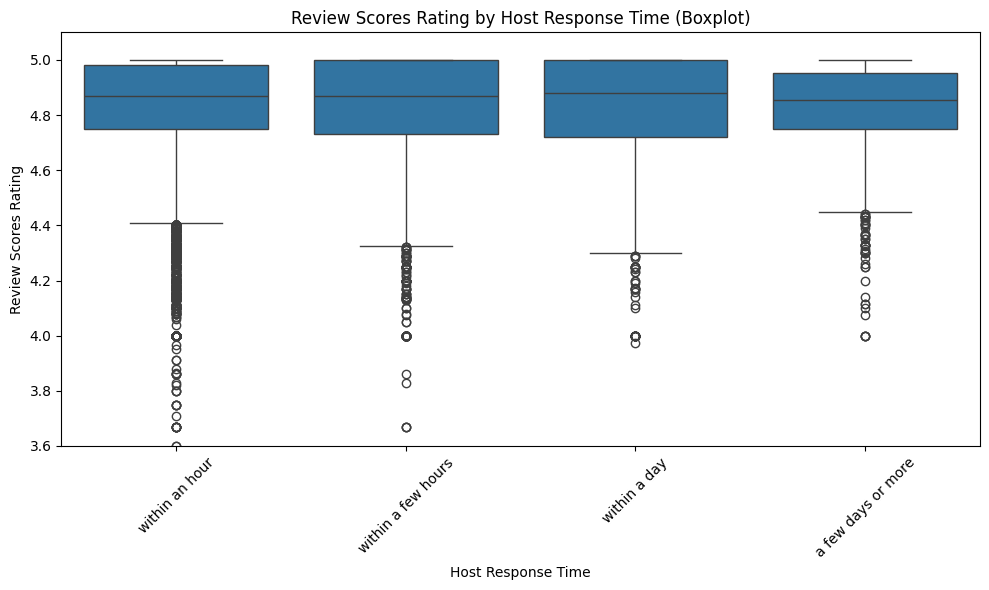

In [ ]:
plot_data = df_listings_limpio[['host_response_time', 'review_scores_rating']].dropna().copy()

order = ['within an hour', 'within a few hours', 'within a day', 'a few days or more']
plot_data['host_response_time'] = pd.Categorical(plot_data['host_response_time'], categories=order, ordered=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='host_response_time', y='review_scores_rating', data=plot_data)
plt.title('Review Scores Rating by Host Response Time (Boxplot)')
plt.xlabel('Host Response Time')
plt.ylabel('Review Scores Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(3.6, 5.1)
plt.show()


#### 💡 Conclusión preliminar

A simple vista, las diferencias entre grupos son **mínimas**.  
No se observa una variación clara en los puntajes promedio según la rapidez de respuesta, lo que sugiere que este factor **no tendría una influencia significativa** en la valoración final del huésped.


#### 📏 Confirmación estadística

Para verificar si existen diferencias significativas entre los grupos se aplica el siguiente enfoque:

1. **Test de Shapiro–Wilk** → verifica la normalidad de `review_scores_rating` dentro de cada grupo de `host_response_time`.  
2. Dado que las distribuciones **no son normales**, se utiliza el **test no paramétrico de Kruskal–Wallis** para comparar las medianas entre grupos.

---

### Fundamentación teórica

#### 🧪 Test de Shapiro–Wilk
Determina si los datos provienen de una distribución normal.  
- **H₀:** los datos son normales.  
- **H₁:** los datos no son normales.  
Si **p ≤ 0.05**, se rechaza la normalidad.  
Este paso define el tipo de test estadístico a aplicar.

---

#### 📈 Test de Kruskal–Wallis
Alternativa al ANOVA para datos **no normales o con outliers**.  
Compara las **medianas** entre múltiples grupos.  
- **H₀:** todas las medianas son iguales.  
- **H₁:** al menos una difiere.  
Si **p < 0.05**, hay diferencias estadísticamente significativas.

---

### 🔍 Conclusión metodológica
1. Se comprueba **no normalidad** en los grupos mediante Shapiro–Wilk.  
2. Se aplica **Kruskal–Wallis** para comparar medianas de `review_scores_rating`.  
3. El resultado muestra **p > 0.05**, indicando que **no existen diferencias significativas** entre los grupos.


In [ ]:
plot_data.head()

,host_response_time,review_scores_rating
0,within an hour,4.82
1,within an hour,4.77
2,within an hour,4.65
3,within an hour,4.28
4,within an hour,4.93


In [ ]:
# Test de normalidad separando por grupos de host response time
host_response_time_groups = plot_data['host_response_time'].unique()

shapiro_results = {}

for group in host_response_time_groups:
    subset_df = plot_data[plot_data['host_response_time'] == group].dropna(subset=['review_scores_rating'])

    # Test for review_scores_rating
    if len(subset_df['review_scores_rating'].dropna()) > 0:
        stat_rating, p_rating = shapiro(subset_df['review_scores_rating'].dropna())
        shapiro_results[group] = {"Statistics": stat_rating, "p": p_rating}
    else:
        shapiro_results[group] = "Not enough data"

print("\n--- Shapiro-Wilk Test Results for Review Scores Rating by Host Response Time ---")
for group, result in shapiro_results.items():
    if isinstance(result, dict):
        print(f"'{group}': Statistics={result['Statistics']:.4f}, p={result['p']:.4f}")
    else:
        print(f"'{group}': {result}")


--- Shapiro-Wilk Test Results for Review Scores Rating by Host Response Time ---
'within an hour': Statistics=0.8117, p=0.0000
'within a few hours': Statistics=0.8045, p=0.0000
'within a day': Statistics=0.8258, p=0.0000
'a few days or more': Statistics=0.8659, p=0.0000


In [ ]:
# Perform Kruskal-Wallis test on review_scores_rating by host_response_time

# Create a list of review_scores_rating for each host_response_time group, dropping NaN values
rating_groups_by_time = [plot_data[plot_data['host_response_time'] == group]['review_scores_rating'].dropna() for group in plot_data['host_response_time'].unique()]

# Perform the Kruskal-Wallis test
statistic_rating_time, p_value_rating_time = stats.kruskal(*rating_groups_by_time)

print(f"\nTest de Kruskal-Wallis para Review Scores Rating por Host Response Time:")
print(f"Statistics={statistic_rating_time:.4f}, p={p_value_rating_time:.4f}")

if p_value_rating_time < 0.05:
    print("Resultado: Rechazamos la hipótesis nula. Existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de tiempo de respuesta del host.")
else:
    print("Resultado: No rechazamos la hipótesis nula. No existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de tiempo de respuesta del host.")


Test de Kruskal-Wallis para Review Scores Rating por Host Response Time:
Statistics=6.6947, p=0.0823
Resultado: No rechazamos la hipótesis nula. No existe una diferencia estadísticamente significativa entre las medianas de los review scores rating de los diferentes grupos de tiempo de respuesta del host.


### 🧭 Conclusión final

El análisis estadístico confirma la **ausencia de relación significativa** entre el **tiempo de respuesta del anfitrión** y las **calificaciones obtenidas**.  
Aunque podría esperarse que una respuesta más rápida genere mejor percepción, en este caso el comportamiento de los huéspedes **no refleja una influencia estadísticamente relevante** de este factor en el puntaje promedio.


### Hipótesis 4:
Existe una **relación entre el score de reviews de limpieza** y el **score de reviews de ubicación**.

---

#### 🧹 Planteo del análisis

El objetivo es analizar si los huéspedes que califican **alta la ubicación** también tienden a valorar **mejor la limpieza** del alojamiento.

Ambas variables (`review_scores_location` y `review_scores_cleanliness`) son **puntuaciones numéricas** que reflejan la percepción del usuario en distintos aspectos del hospedaje.  
Una correlación positiva indicaría que los alojamientos mejor ubicados suelen tener también estándares más altos de limpieza.


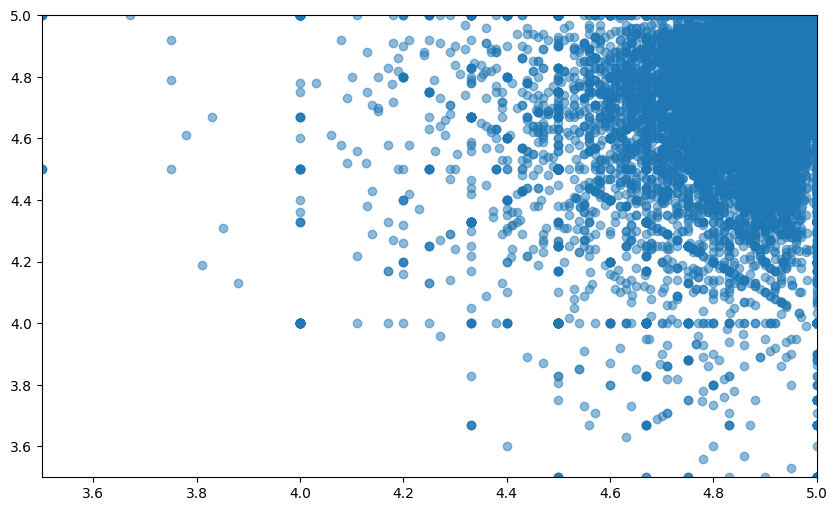

In [ ]:
plt.figure(figsize=(10, 6))
plt.ylim(3.5, 5)
plt.xlim(3.5, 5)
plt.scatter(df_listings_limpio['review_scores_location'], df_listings_limpio['review_scores_cleanliness'], alpha=0.5)


#### 📊 Análisis exploratorio

Se realiza un **gráfico de dispersión (scatterplot)** para observar la relación entre ambas variables:

- Eje X → `review_scores_location`  
- Eje Y → `review_scores_cleanliness`  

Cada punto representa un alojamiento.  
El rango de valores se acota entre **3.5 y 5**, que concentra la mayoría de las puntuaciones.

> Este gráfico permite observar visualmente si existe una tendencia creciente entre ambas variables.

---

#### 💡 Conclusión preliminar

Visualmente, se aprecia una **tendencia ascendente**: a mayor calificación en **ubicación**, tiende a observarse también un mayor puntaje de **limpieza**.  
Esto sugiere una posible **relación positiva moderada** entre ambas variables, aunque aún debe confirmarse estadísticamente.



#### 📏 Confirmación estadística

Para evaluar formalmente la relación se siguen estos pasos:

1. **Test de normalidad (Shapiro–Wilk):**  
   Se verifica si las variables `review_scores_location` y `review_scores_cleanliness` siguen una distribución normal.  
   Como en otros casos, se espera **no normalidad** por la concentración de valores altos.

2. **Coeficiente de correlación de Spearman:**  
   Dado que no se asume normalidad, se utiliza el método **no paramétrico de Spearman**, que mide la **fuerza y dirección** de una relación **monótona** entre variables numéricas.  
   - Valores cercanos a **1** → fuerte correlación positiva  
   - Valores cercanos a **-1** → fuerte correlación negativa  
   - Valores cercanos a **0** → sin correlación  


In [ ]:
location_scores = df_listings_limpio['review_scores_location']
cleanliness_scores = df_listings_limpio['review_scores_cleanliness']
print("Test Shapiro para review_scores_location:", shapiro(location_scores))
print("Test Shapiro para review_scores_cleanliness:", shapiro(cleanliness_scores))

Test Shapiro para review_scores_location: ShapiroResult(statistic=np.float64(0.717943786536424), pvalue=np.float64(1.9913653367512955e-114))
Test Shapiro para review_scores_cleanliness: ShapiroResult(statistic=np.float64(0.8019967037110096), pvalue=np.float64(5.216140601573865e-105))


In [ ]:
combined_scores = df_listings_limpio[['review_scores_location', 'review_scores_cleanliness']]

# Calcular la correlación de Spearman
correlation, p_value = spearmanr(combined_scores['review_scores_location'], combined_scores['review_scores_cleanliness'])

print(f"\nCoeficiente de Correlación de Spearman: {correlation:.4f}")
print(f"P-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Resultado: Rechazamos la hipótesis nula (no correlación). Existe una relación estadísticamente significativa.")
else:
    print("Resultado: No rechazamos la hipótesis nula. No hay evidencia de una relación estadísticamente significativa.")

if correlation > 0.5:
    print("Interpretación: Existe una correlación positiva fuerte entre el score de ubicación y el de limpieza.")
elif correlation > 0.1:
    print("Interpretación: Existe una correlación positiva moderada entre el score de ubicación y el de limpieza.")
elif correlation < -0.5:
    print("Interpretación: Existe una correlación negativa fuerte entre el score de ubicación y el de limpieza.")
elif correlation < -0.1:
    print("Interpretación: Existe una correlación negativa moderada entre el score de ubicación y el de limpieza.")
else:
    print("Interpretación: La correlación entre el score de ubicación y el de limpieza es débil o nula.")


Coeficiente de Correlación de Spearman: 0.3491
P-valor: 0.0000
Resultado: Rechazamos la hipótesis nula (no correlación). Existe una relación estadísticamente significativa.
Interpretación: Existe una correlación positiva moderada entre el score de ubicación y el de limpieza.



### Fundamentación teórica

#### 🧪 Test de Shapiro–Wilk
Permite determinar si una variable proviene de una distribución normal.  
- **H₀:** los datos son normales.  
- **H₁:** los datos no son normales.  
Si **p ≤ 0.05**, se rechaza la normalidad.

---

#### 🔗 Coeficiente de correlación de Spearman
Evalúa la relación entre dos variables **no necesariamente lineales**.  
- **H₀:** no existe correlación entre las variables.  
- **H₁:** existe correlación (positiva o negativa).  
Si **p < 0.05**, la correlación es estadísticamente significativa.  
La magnitud del coeficiente determina la fuerza del vínculo.

---

### 🔍 Conclusión metodológica
1. Ambas variables **no siguen distribución normal** (según Shapiro–Wilk).  
2. Se aplica **Spearman** para evaluar la relación.  
3. El resultado muestra un coeficiente de **ρ = 0.35** con **p < 0.001**, indicando:
   - **Correlación positiva moderada.**
   - **Significativa estadísticamente.**

---

### 🧭 Conclusión final

El análisis confirma que existe una **relación positiva y significativa** entre la calificación de **ubicación** y la de **limpieza**.  
Aunque la correlación no es muy fuerte, el patrón sugiere que los alojamientos mejor ubicados suelen mantener también **estándares más altos de limpieza**, lo que respalda la hipótesis planteada.

---

# Pre-Procesamiento para Machine Learning

## Variables categoricas
En esta sección se preparan las variables del dataset para su uso en modelos de aprendizaje automático.  
El objetivo es transformar los datos crudos en un formato **numérico, limpio y estructurado**, eliminando texto libre y codificando categorías.

Se aplican distintos métodos de codificación según el tipo de variable:
- **One Hot Encoding** → para variables categóricas nominales.  
- **Ordinal Encoding** → para variables categóricas con orden lógico.  

Estas transformaciones permiten que los algoritmos puedan interpretar correctamente la información.


### One Hot Encoding

Antes de aplicar la codificación, se agrupan los **barrios** en sus respectivas **comunas** de la Ciudad de Buenos Aires.  
Esto simplifica la representación geográfica y reduce la cantidad de categorías en el modelo.

Cada barrio se asigna manualmente a una comuna según la división administrativa oficial de CABA.  
Los barrios no reconocidos se etiquetan como `'Comuna Desconocida'`.


In [ ]:
# Mapeo de barrios a comunas de CABA (se puede ajustar y completar según necesidad)
neighborhood_to_comuna_mapping = {
    'Retiro': 'Comuna 1',
    'San Nicolas': 'Comuna 1',
    'Puerto Madero': 'Comuna 1',
    'San Telmo': 'Comuna 1',
    'Monserrat': 'Comuna 1',
    'Constitucion': 'Comuna 1',
    'Recoleta': 'Comuna 2',
    'Balvanera': 'Comuna 3',
    'San Cristobal': 'Comuna 3',
    'Boca': 'Comuna 4',
    'Barracas': 'Comuna 4',
    'Parque Patricios': 'Comuna 4',
    'Nueva Pompeya': 'Comuna 4',
    'Almagro': 'Comuna 5',
    'Boedo': 'Comuna 5',
    'Caballito': 'Comuna 6',
    'Flores': 'Comuna 7',
    'Parque Chacabuco': 'Comuna 7',
    'Villa Lugano': 'Comuna 8',
    'Villa Riachuelo': 'Comuna 8',
    'Villa Soldati': 'Comuna 8',
    'Parque Avellaneda': 'Comuna 9',
    'Liniers': 'Comuna 9',
    'Mataderos': 'Comuna 9',
    'Floresta': 'Comuna 10',
    'Monte Castro': 'Comuna 10',
    'Velez Sarsfield': 'Comuna 10',
    'Versalles': 'Comuna 10',
    'Villa Luro': 'Comuna 10',
    'Villa Real': 'Comuna 10',
    'Villa Devoto': 'Comuna 11',
    'Villa Del Parque': 'Comuna 11',
    'Villa Gral. Mitre': 'Comuna 11',
    'Villa Santa Rita': 'Comuna 11',
    'Coghlan': 'Comuna 12',
    'Saavedra': 'Comuna 12',
    'Villa Urquiza': 'Comuna 12',
    'Villa Pueyrredon': 'Comuna 12',
    'Belgrano': 'Comuna 13',
    'Nuñez': 'Comuna 13',
    'Colegiales': 'Comuna 13',
    'Palermo': 'Comuna 14',
    'Agronomia': 'Comuna 15',
    'Chacarita': 'Comuna 15',
    'Parque Chas': 'Comuna 15',
    'Paternal': 'Comuna 15',
    'Villa Crespo': 'Comuna 15',
    'Villa Ortuzar': 'Comuna 15',
    'Agronomía': 'Comuna 15', # A veces con tilde
    'Núñez': 'Comuna 13',   # A veces con tilde
    'Villa General Mitre': 'Comuna 11' # Nombre completo
}

def map_neighbourhood_to_comuna(df):
    # Crear la nueva columna 'comuna' aplicando el mapeo
    df['comuna'] = df['neighbourhood_cleansed'].map(neighborhood_to_comuna_mapping)
    # Manejar barrios que no estén en el mapeo (opcional: asignar 'Desconocido' o mantener NaN)
    df['comuna'] = df['comuna'].fillna('Comuna Desconocida')
    return df

# Aplicar la función a df_listings_limpio
df_listings_limpio = map_neighbourhood_to_comuna(df_listings_limpio)

#Creamos un nuevo df donde solo estan las comunas
df_machine_learning=df_listings_limpio.copy()

Se genera una copia del dataset limpio (`df_listings_limpio`) llamada `df_machine_learning`,  
que será la base sobre la cual se aplicarán todas las transformaciones necesarias para modelado.

En esta etapa se revisan los valores de `property_type` y `room_type`  
para identificar categorías que luego serán codificadas mediante **One Hot Encoding**.


In [ ]:
#NOS QUEDAMOS SOLO CON ROOM_Type
print(df_machine_learning['property_type'].unique())
print(df_machine_learning['room_type'].unique())

['Entire condo' 'Entire rental unit' 'Private room in rental unit'
 'Entire loft' 'Entire serviced apartment' 'Private room in home'
 'Room in aparthotel' 'Entire home' 'Entire townhouse'
 'Private room in bed and breakfast' 'Camper/RV' 'Entire guest suite'
 'Private room' 'Private room in guesthouse' 'Private room in villa'
 'Private room in condo' 'Private room in townhouse' 'Entire place'
 'Private room in hostel' 'Room in hostel' 'Casa particular'
 'Private room in serviced apartment' 'Shared room in villa'
 'Room in serviced apartment' 'Private room in chalet' 'Entire guesthouse'
 'Entire vacation home' 'Entire villa' 'Room in boutique hotel'
 'Entire bungalow' 'Private room in loft' 'Tiny home' 'Room in hotel'
 'Shared room in hostel' 'Private room in guest suite' 'Entire home/apt'
 'Private room in casa particular' 'Shared room in rental unit'
 'Entire in-law' 'Room in bed and breakfast' 'Shared room in home'
 'Entire cabin' 'Private room in religious building' 'Castle'
 'Entire

El **One Hot Encoding** transforma las variables categóricas nominales en columnas binarias (0/1), una por cada categoría.  
Por ejemplo:  
`Comuna 1` → columna “Comuna 1” con valor 1 si el alojamiento pertenece a esa comuna.

Se aplica este método sobre:
- `comuna` (representa la ubicación general dentro de CABA)  
- `room_type` (tipo de alojamiento: habitación privada, casa completa, etc.)

> Este proceso evita pérdida de información, pero puede aumentar significativamente el número de columnas.


In [ ]:
# One Hot Encoding con barrios
df_machine_learning = pd.get_dummies(df_machine_learning, columns=['comuna'], prefix='', prefix_sep='')
# One Hot Encoding con property_type_grouped
df_machine_learning = pd.get_dummies(df_machine_learning, columns=['room_type'], prefix='', prefix_sep='')

### Ordinal Encoding

A diferencia del One Hot Encoding, el **Ordinal Encoding** se usa para variables con un **orden lógico o jerárquico**.  
En este caso, la variable `host_response_time` refleja el tiempo promedio que tarda el anfitrión en responder.

Se asignan valores numéricos según su rapidez de respuesta:

| host_response_time | Valor asignado |
|--------------------|----------------|
| within an hour | 0 |
| within a few hours | 1 |
| within a day | 2 |
| a few days or more | 3 |

De esta forma, los algoritmos pueden interpretar correctamente la **relación ordinal** entre las categorías.


In [ ]:
# Definir el orden ordinal para host_response_time
# Asignamos valores numéricos a cada categoría según su orden natural
response_time_order = {
    'within an hour': 0,
    'within a few hours': 1,
    'within a day': 2,
    'a few days or more': 3
}

# Crear la nueva columna ordinal
df_machine_learning['host_response_time_ordinal'] = df_machine_learning['host_response_time'].map(response_time_order)

# Mostrar las primeras filas con la nueva columna y la original para verificar
display(df_machine_learning[['host_response_time', 'host_response_time_ordinal']].head())

# Verificar que no haya NaNs introducidos por el mapeo si hay categorías no mapeadas
print(df_machine_learning['host_response_time_ordinal'].value_counts(dropna=False))

,host_response_time,host_response_time_ordinal
0,within an hour,0
1,within an hour,0
2,within an hour,0
3,within an hour,0
4,within an hour,0


host_response_time_ordinal
0    25672
1     4660
2     1848
3     1233
Name: count, dtype: int64


Finalmente, se eliminan columnas **no numéricas o redundantes** que no aportan valor al modelo.  
Esto incluye identificadores, texto libre, descripciones y variables que ya fueron transformadas.

El resultado es un dataset **exclusivamente numérico**, listo para la etapa de **normalización y modelado predictivo**.


In [ ]:
df_machine_learning.drop(columns=['id','name','neighbourhood_cleansed','description','host_id','bathrooms_text','amenities','amenity_combination','host_response_time','property_type'], inplace=True)

## Variables Numéricas

En esta sección se procesan las variables numéricas para adaptarlas a los requerimientos de los modelos de Machine Learning.  
El objetivo es **homogeneizar escalas**, crear variables derivadas útiles (como la antigüedad del host) y dejar todas las columnas listas para normalización o estandarización.


###  Conversión de fechas a variable numérica: `antigüedad`

La columna `host_since` representa la fecha en la que cada anfitrión comenzó a operar en la plataforma.  
Para poder utilizarla en modelos, se transforma en una **variable numérica continua** que indica la **antigüedad del host en años**.

Pasos aplicados:
1. Se calcula la diferencia entre la fecha actual y la fecha de registro del host.  
2. El resultado (en días) se convierte a años dividiendo por 365.25.  
3. Se elimina la columna original `host_since` y se conservan únicamente los valores válidos (sin `NaN`).

> Esta transformación permite capturar la experiencia del anfitrión como un posible factor explicativo del precio o de la valoración.


In [ ]:
# Calcular la antigüedad en años para host_since y renombrar la columna

# Calcular la antigüedad en años
current_date = pd.to_datetime('today')
df_machine_learning['antiguedad'] = (current_date - df_listings_limpio['host_since']).dt.days / 365.25

# Eliminar la columna original 'host_since' de df_machine_learning
df_machine_learning.drop(columns=['host_since'], inplace=True)

#borramos los Nan
df_machine_learning.dropna(subset=['antiguedad'], inplace=True)

# Mostrar las primeras filas con la nueva columna
display(df_machine_learning[['antiguedad']].head())

,antiguedad
0,16.131417
1,9.292266
2,15.961670
3,15.909651
4,15.797399


### Normalización y estandarización de variables numéricas

Para garantizar que todas las variables numéricas tengan **escalas comparables**, se aplican dos tipos de transformaciones:

#### 🔸 MinMaxScaler
- **Qué hace:** escala los valores dentro de un rango específico (por defecto, [0, 1]).  
- **Fórmula:**  
  \[
  X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
  \]
- **Ventaja:** mantiene la proporción entre valores y asegura un rango acotado.  
- **Desventaja:** es sensible a los *outliers* (un valor extremo puede distorsionar todo el rango).  
- **Uso típico:** cuando se necesitan datos en un rango fijo (por ejemplo, para redes neuronales o imágenes).

#### 🔹 StandardScaler
- **Qué hace:** centra los datos en torno a la media (0) y los escala según la desviación estándar (1).  
- **Ventaja:** útil para modelos que asumen normalidad (p. ej., regresión lineal o PCA).  
- **Desventaja:** los valores extremos aún pueden influir en la escala.  
- **Uso típico:** en algoritmos sensibles a la magnitud de las features (SVM, K-means, etc.).

> Ambas técnicas se aplican sobre las mismas variables para poder comparar resultados entre modelos normalizados y estandarizados.


In [ ]:
df_machine_learning.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33407 entries, 0 to 33412
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   host_response_rate           33407 non-null  float64
 1   host_acceptance_rate         33407 non-null  float64
 2   host_is_superhost            33407 non-null  bool   
 3   host_identity_verified       33407 non-null  bool   
 4   accommodates                 33407 non-null  float64
 5   bathrooms                    33407 non-null  float64
 6   bedrooms                     33407 non-null  float64
 7   beds                         33407 non-null  int64  
 8   price                        33407 non-null  float64
 9   minimum_nights               33407 non-null  float64
 10  maximum_nights               33407 non-null  float64
 11  availability_90              33407 non-null  float64
 12  number_of_reviews_ltm        33407 non-null  float64
 13  review_scores_rating 



Se seleccionan las columnas numéricas relevantes del dataset, incluyendo métricas de respuesta del host, cantidad de habitaciones, noches mínimas, disponibilidad y puntajes de review.

Luego se aplican los dos escaladores:
- `MinMaxScaler` → genera el dataset `df_machine_learning_MinMax`
- `StandardScaler` → genera el dataset `df_machine_learning_StandardScaler`

Ambos DataFrames mantienen la misma estructura pero con los valores escalados de forma diferente.  
Esto permite experimentar con distintos modelos y ver cuál tipo de escalado se adapta mejor al rendimiento predictivo.

Finalmente, se muestran las primeras filas de cada uno para verificar la transformación.


In [ ]:
df_machine_learning_MinMax = df_machine_learning.copy()
df_machine_learning_StandardScaler = df_machine_learning.copy()

# Define the columns to be scaled
columns_to_scale = [
    'host_response_rate', 'host_acceptance_rate', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
    'availability_90', 'number_of_reviews_ltm', 'review_scores_rating',
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value', 'antiguedad'
]

# Initialize the scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

# Apply MinMaxScaler
df_machine_learning_MinMax[columns_to_scale] = min_max_scaler.fit_transform(
    df_machine_learning_MinMax[columns_to_scale]
)

# Apply StandardScaler
df_machine_learning_StandardScaler[columns_to_scale] = standard_scaler.fit_transform(
    df_machine_learning_StandardScaler[columns_to_scale]
)

print("df_machine_learning_MinMax head:")
display(df_machine_learning_MinMax[columns_to_scale].head())

print("df_machine_learning_StandardScaler head:")
display(df_machine_learning_StandardScaler[columns_to_scale].head())

df_machine_learning_MinMax head:


,host_response_rate,host_acceptance_rate,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_value,antiguedad
0,1.00,0.79,0.066667,0.111111,0.028571,0.066667,0.002002,0.01124,0.277778,0.014706,0.9550,0.9825,0.960000,0.9825,0.993333,0.9650,0.970522
1,1.00,1.00,0.066667,0.111111,0.028571,0.066667,0.006006,0.00039,0.488889,0.023529,0.9425,0.9400,0.923333,0.9550,0.966667,0.9375,0.537368
2,0.98,0.93,0.000000,0.111111,0.028571,0.133333,0.028028,0.00729,0.000000,0.000000,0.9125,0.9395,0.866667,0.9710,0.954667,0.9180,0.959771
3,0.95,0.94,0.200000,0.111111,0.028571,0.066667,0.001001,0.01124,1.000000,0.000000,0.8200,0.8975,0.763333,0.9575,0.933333,0.8525,0.956477
4,1.00,0.99,0.200000,0.166667,0.057143,0.133333,0.001001,0.00364,0.322222,0.073529,0.9825,0.9800,0.956667,0.9850,0.976667,0.9475,0.949367


df_machine_learning_StandardScaler head:


,host_response_rate,host_acceptance_rate,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_90,number_of_reviews_ltm,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_value,antiguedad
0,0.335029,-0.272094,-0.682611,-0.409837,-0.181851,-0.723990,-0.115218,1.080460,-0.895356,-0.340922,-0.012853,0.445513,0.413103,0.221292,0.550554,0.315751,2.213192
1,0.335029,0.582207,-0.682611,-0.409837,-0.181851,-0.723990,0.059828,-0.559904,-0.316194,-0.129251,-0.267785,-0.505403,-0.050599,-0.485825,0.038274,-0.198216,0.394199
2,0.224396,0.297440,-1.484777,-0.409837,-0.181851,0.163582,1.022578,0.483277,-1.657410,-0.693707,-0.879621,-0.516591,-0.767229,-0.074412,-0.192252,-0.562665,2.168045
3,0.058446,0.338121,0.921721,-0.409837,-0.181851,-0.723990,-0.158979,1.080460,1.085985,-0.693707,-2.766118,-1.456320,-2.074025,-0.421542,-0.602076,-1.786840,2.154209
4,0.335029,0.541526,0.921721,0.661564,1.131683,0.163582,-0.158979,-0.068550,-0.773427,1.070219,0.547998,0.389577,0.370948,0.285575,0.230379,-0.011319,2.124354


## Revisión de Multicolinealidad

En esta sección se analiza la **correlación y redundancia entre variables numéricas**, con el objetivo de detectar posibles problemas de multicolinealidad antes del modelado.

La multicolinealidad ocurre cuando dos o más variables explicativas están fuertemente correlacionadas entre sí, lo que puede distorsionar los coeficientes de un modelo lineal o dificultar la interpretación de su importancia.


### Análisis visual de correlaciones

Se calculan y visualizan las **matrices de correlación** entre las variables numéricas escaladas (tanto con `StandardScaler` como con `MinMaxScaler`).

- Los valores cercanos a **1 o -1** indican una correlación fuerte (positiva o negativa).  
- Los valores cercanos a **0** indican independencia lineal.

> Este paso permite identificar de forma visual variables que podrían estar aportando información redundante al modelo.  
> Si hay muchas correlaciones altas, conviene complementar el análisis con métricas más precisas, como el **VIF (Variance Inflation Factor)**.


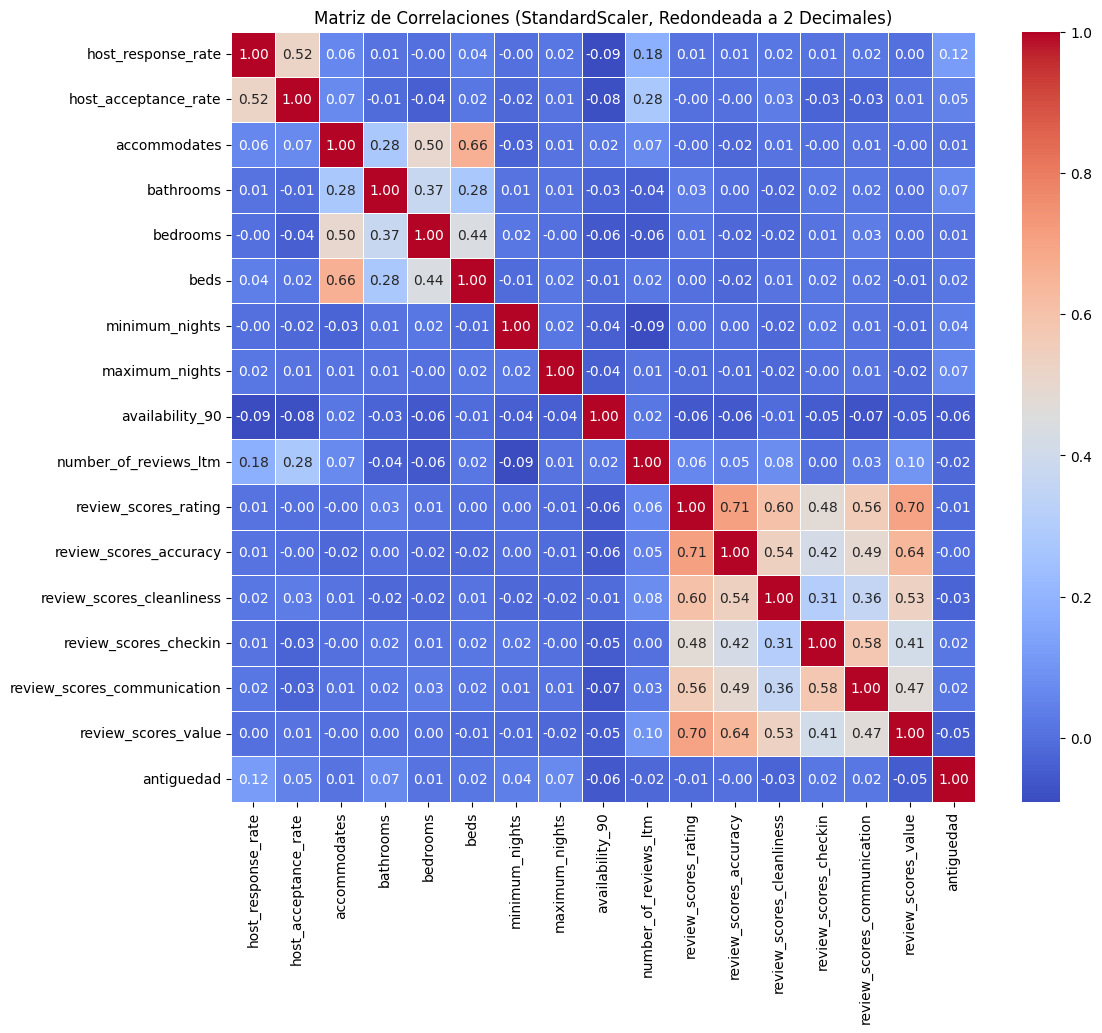

In [ ]:
#matriz de correlaciones en las numericas que le aplicamos escalado
plt.figure(figsize=(12, 10)) # Aumentar el tamaño para mejor visualización
corr_matrix = df_machine_learning_StandardScaler[columns_to_scale].corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # fmt para redondear anotaciones
plt.title('Matriz de Correlaciones (StandardScaler, Redondeada a 2 Decimales)')
plt.show()

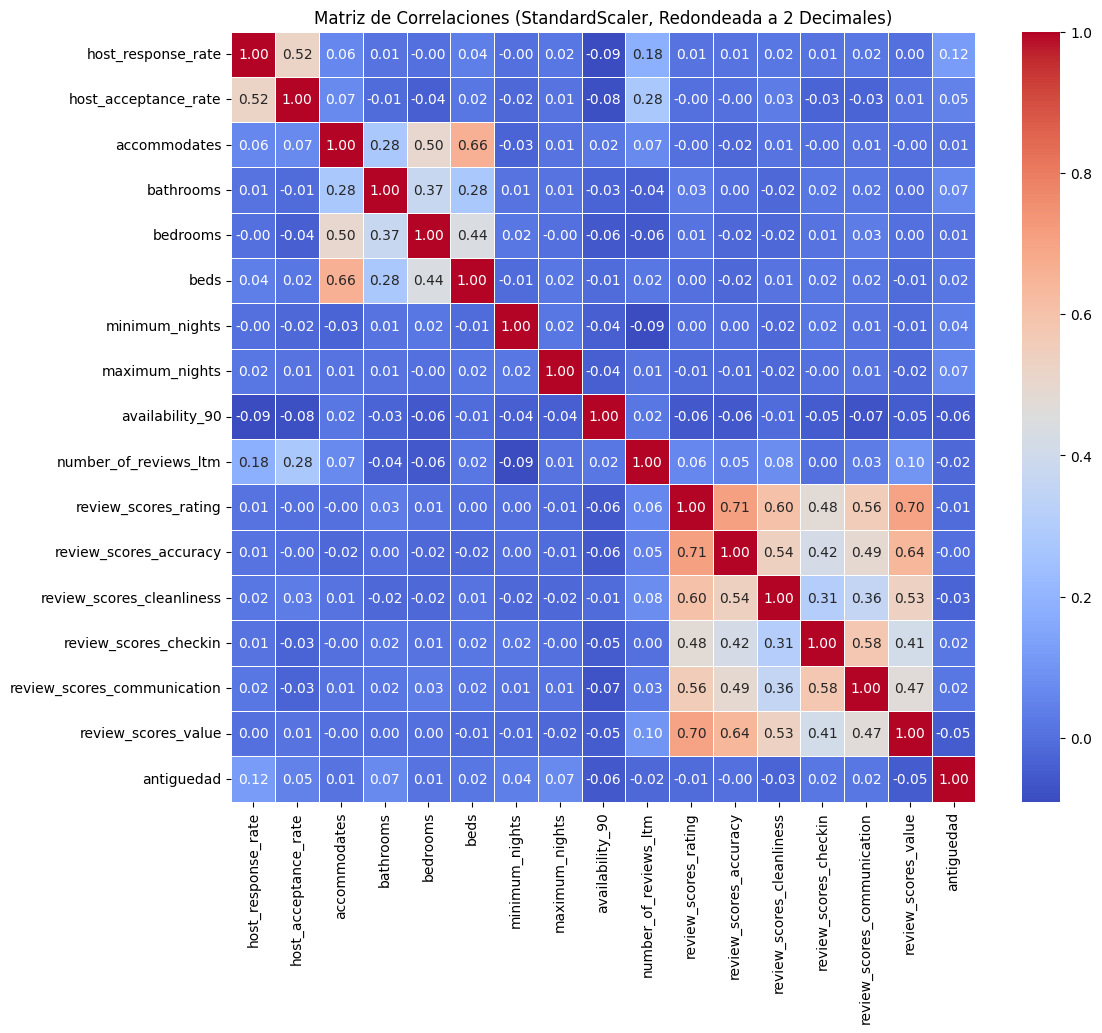

In [ ]:
#matriz de correlaciones en las numericas que le aplicamos escalado
plt.figure(figsize=(12, 10)) # Aumentar el tamaño para mejor visualización
corr_matrix = df_machine_learning_MinMax[columns_to_scale].corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # fmt para redondear anotaciones
plt.title('Matriz de Correlaciones (StandardScaler, Redondeada a 2 Decimales)')
plt.show()

### Cálculo del Factor de Inflación de la Varianza (VIF)

El **Variance Inflation Factor (VIF)** cuantifica cuánta varianza de un coeficiente de regresión se “infla” debido a la correlación con otras variables.

- **Fórmula:**  
  \[
  VIF_i = \frac{1}{1 - R_i^2}
  \]
  donde \( R_i^2 \) es el coeficiente de determinación al predecir la variable *i* usando todas las demás.

**Interpretación general:**
| VIF | Interpretación |
|-----|----------------|
| 1 – 5 | Correlación baja o moderada (aceptable) |
| > 10 | Multicolinealidad severa — la variable debería revisarse o eliminarse |

En esta etapa:
- Se calculan los VIF para cada variable numérica en las versiones **StandardScaler** y **MinMaxScaler**.  
- Luego se ordenan de mayor a menor para identificar las variables más redundantes.

> Si una variable tiene un VIF alto, probablemente aporte información ya explicada por otras variables, y conviene considerar su eliminación.


In [ ]:
# Asegurarse de que no haya NaNs en las columnas antes de calcular VIF
X = df_machine_learning_StandardScaler[columns_to_scale].dropna()

# Crear un DataFrame para almacenar los resultados del VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calcular VIF para cada característica
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Ordenar por VIF en orden descendente y mostrar
display(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))

,feature,VIF
0,review_scores_rating,3.028253
1,review_scores_accuracy,2.286490
2,review_scores_value,2.245522
3,accommodates,2.022322
4,beds,1.853101
5,review_scores_communication,1.816434
6,review_scores_cleanliness,1.687693
7,review_scores_checkin,1.600068
8,bedrooms,1.502053
9,host_acceptance_rate,1.470282


El análisis del **VIF** aplicado sobre las variables escaladas con **StandardScaler** muestra que **ninguna variable supera el umbral de 10**, y de hecho la mayoría se mantiene en valores bajos (entre 1 y 3).  

Esto indica que **no existe multicolinealidad severa** dentro de este conjunto de variables:  
- Las variables aportan información relativamente independiente entre sí.  
- No es necesario eliminar ninguna en esta etapa.

> En resumen, el escalado con *StandardScaler* preserva la independencia estadística entre las variables numéricas, lo que lo convierte en una buena base para el modelado posterior.








In [ ]:
df_machine_learning_MinMax.isna().sum()

,0
host_response_rate,0
host_acceptance_rate,0
host_is_superhost,0
host_identity_verified,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
price,0
minimum_nights,0


In [ ]:
# Asegurarse de que no haya NaNs en las columnas antes de calcular VIF
X = df_machine_learning_MinMax[columns_to_scale]

# Crear un DataFrame para almacenar los resultados del VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calcular VIF para cada característica
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Ordenar por VIF en orden descendente y mostrar
display(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))

,feature,VIF
0,review_scores_rating,1152.248972
1,review_scores_accuracy,975.005795
2,review_scores_checkin,746.649029
3,review_scores_value,704.286501
4,review_scores_communication,625.208437
5,review_scores_cleanliness,231.589324
6,host_response_rate,38.741457
7,host_acceptance_rate,19.204301
8,bathrooms,8.964561
9,beds,6.665350


In [ ]:
#ahora borramos review_scores_rating de Min Max y volvemos a calcular el vif
columns_min_max_vif= [
    'host_response_rate', 'host_acceptance_rate', 'accommodates',
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
    'availability_90', 'number_of_reviews_ltm',
    'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_value', 'antiguedad'
]

X = df_machine_learning_MinMax[columns_min_max_vif]

# Crear un DataFrame para almacenar los resultados del VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calcular VIF para cada característica
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Ordenar por VIF en orden descendente y mostrar
display(vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True))


,feature,VIF
0,review_scores_accuracy,850.170821
1,review_scores_checkin,730.385947
2,review_scores_value,615.259738
3,review_scores_communication,599.281153
4,review_scores_cleanliness,214.910940
5,host_response_rate,38.735241
6,host_acceptance_rate,19.203054
7,bathrooms,8.948270
8,beds,6.665349
9,accommodates,6.479902


### Eliminación iterativa de variables con alto VIF

Para automatizar la detección y eliminación de variables redundantes, se define una función que:
1. Calcula los **VIF** de todas las variables seleccionadas.
2. Identifica la variable con **mayor VIF**.
3. Si supera el umbral (por defecto **VIF > 10**), la elimina del conjunto.
4. Repite el proceso hasta que todas las variables restantes tengan VIF aceptables.

De esta forma se obtiene una versión más estable y sin multicolinealidad excesiva del dataset.  
Este procedimiento evita que el modelo aprenda relaciones artificiales causadas por variables altamente correlacionadas.

> En este caso, se aplicó el proceso sobre el dataset **MinMaxScaler**, reduciendo progresivamente las variables hasta mantener solo aquellas con VIF < 10.


In [ ]:
def remove_high_vif_features(df, features, vif_threshold=10):
    """
    Iteratively removes features with VIF above a specified threshold.

    Args:
        df (pd.DataFrame): The input DataFrame containing all features.
        features (list): A list of column names (features) to consider for VIF analysis.
        vif_threshold (float, optional): The VIF threshold above which features are removed.
                                        Defaults to 10.

    Returns:
        tuple: A tuple containing:
            - pd.DataFrame: The original DataFrame (df) without any columns actually dropped.
            - list: The updated list of feature names with VIF below the threshold.
    """
    current_features = list(features)

    print(f"\nStarting VIF analysis with {len(current_features)} features...")
    while True:
        X = df[current_features]
        X = X.dropna()
        if X.empty or X.shape[1] <= 1:
            print("Not enough data or features to compute VIF. Stopping.")
            break

        for col in X.columns:
            if not pd.api.types.is_numeric_dtype(X[col]):

                print(f"Warning: Non-numeric feature '{col}' found. Removing from VIF analysis.")
                current_features.remove(col)
                continue


        X = df[current_features].dropna()
        if X.empty or X.shape[1] <= 1:
            print("Not enough data or features to compute VIF after non-numeric removal. Stopping.")
            break

        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

        vif_data_sorted = vif_data.sort_values(by="VIF", ascending=False)
        highest_vif_feature = vif_data_sorted.iloc[0]

        if highest_vif_feature['VIF'] > vif_threshold:
            feature_to_remove = highest_vif_feature['feature']
            current_features.remove(feature_to_remove)
            print(f"Removing '{feature_to_remove}' with VIF: {highest_vif_feature['VIF']:.2f}")
        else:
            print(f"All remaining features have VIF below {vif_threshold}.")
            break

    print(f"VIF analysis completed. Retained {len(current_features)} features.")
    return df, current_features

print("remove_high_vif_features function defined.")


remove_high_vif_features function defined.


In [ ]:
print("\n--- Applying VIF removal to df_machine_learning_MinMax ---")
df_processed, retained_features = remove_high_vif_features(
    df_machine_learning_MinMax.copy(),
    columns_to_scale,
    vif_threshold=10
)

print("\n--- Final VIF scores for retained features ---")
X_final = df_processed[retained_features].dropna()

vif_data_final = pd.DataFrame()
vif_data_final["feature"] = X_final.columns
vif_data_final["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]

display(vif_data_final.sort_values(by="VIF", ascending=False).reset_index(drop=True))

print(f"\nSummary: Started with {len(columns_to_scale)} features. Ended with {len(retained_features)} features after removing high VIF features. All remaining features have VIF below 10.")


--- Applying VIF removal to df_machine_learning_MinMax ---

Starting VIF analysis with 17 features...
Removing 'review_scores_rating' with VIF: 1152.25
Removing 'review_scores_accuracy' with VIF: 850.17
Removing 'review_scores_checkin' with VIF: 656.31
Removing 'review_scores_value' with VIF: 424.46
Removing 'review_scores_communication' with VIF: 173.16
Removing 'host_response_rate' with VIF: 36.05
Removing 'review_scores_cleanliness' with VIF: 23.37
All remaining features have VIF below 10.
VIF analysis completed. Retained 10 features.

--- Final VIF scores for retained features ---


,feature,VIF
0,host_acceptance_rate,8.173440
1,bathrooms,7.755933
2,beds,6.579145
3,accommodates,6.467263
4,bedrooms,4.789929
5,antiguedad,4.152391
6,availability_90,3.181455
7,number_of_reviews_ltm,1.641940
8,maximum_nights,1.379342
9,minimum_nights,1.050717



Summary: Started with 17 features. Ended with 10 features after removing high VIF features. All remaining features have VIF below 10.


In [ ]:
df_machine_learning_MinMax.drop(columns=['review_scores_rating', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_value', 'review_scores_communication', 'host_response_rate', 'review_scores_cleanliness'], inplace=True)

###Conclusión sobre multicolinealidad

Tras aplicar el análisis de correlación y VIF:
- Se eliminaron las variables con **VIF elevado (>10)**.
- El conjunto final conserva únicamente las features **numéricamente estables e independientes**.

> Esto asegura que los modelos posteriores (como regresión o árboles) no sufran problemas de varianza inflada ni sobreajuste por redundancia entre predictores.
